# Osteoporosis Detection from Dental Periapical Radiographs

## Pipeline Overview

This notebook implements a complete machine learning pipeline for osteoporosis classification from dental X-ray images. The pipeline includes advanced preprocessing techniques, feature extraction methods, and a hybrid deep learning architecture combining convolutional neural networks with handcrafted texture features.

### Pipeline Components

**Data Processing:**
- Advanced image preprocessing with bilateral filtering and CLAHE enhancement
- Texture feature extraction using Local Binary Patterns (LBP) and Gray Level Co-occurrence Matrix (GLCM)
- Data augmentation with MixUp and random transformations

**Model Architecture:**
- Custom CNN with residual connections and CBAM attention mechanism
- Hybrid architecture combining deep features with handcrafted texture features
- Feature fusion layer for optimal classification performance

**Training Strategy:**
- Focal loss with class balancing for handling imbalanced datasets
- OneCycleLR learning rate scheduler with warmup
- Weighted random sampling for balanced batch composition
- Early stopping with patience-based monitoring

**Evaluation and Interpretation:**
- Comprehensive performance metrics (accuracy, precision, recall, F1-score)
- ROC curves and AUC scores for multi-class classification
- Grad-CAM visualization for model interpretability

### Configuration

- Training epochs: 20
- Batch size: 64
- Expected training time: 1.5-2 hours on GPU

## 1. Environment Setup

In [1]:
import os
import sys
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image, ImageEnhance, ImageFilter
import cv2
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision.transforms as transforms

# Texture feature extraction
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from scipy import ndimage

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple MPS (Metal Performance Shaders)")
else:
    device = torch.device('cpu')
    print("Using CPU")

print(f"\nDevice: {device}")
print(f"PyTorch version: {torch.__version__}")

Using GPU: Tesla T4
GPU Memory: 14.6 GB

Device: cuda
PyTorch version: 2.10.0+cu128


## 2. Configuration

In [2]:
CONFIG = {
    'data_dir': '/kaggle/input/datasets/sathishkesavann/osteoporosis-dataset/80x80',
    'img_size': (224, 224),
    'num_channels': 3,
    
    # Training - OPTIMIZED FOR SPEED
    'batch_size': 64,  # Increased from 32
    'epochs': 20,  # Reasonable training time
    'learning_rate': 0.001,
    'weight_decay': 0.01,
    'patience': 7,
    
    # Model
    'num_classes': 3,
    'class_names': ['Normal', 'Osteopenia', 'Osteoporosis'],
    'dropout_rate': 0.5,
    
    # Augmentation
    'mixup_alpha': 0.2,  # MixUp augmentation
    'use_weighted_sampler': True,  # Balance classes in batches
    
    # Texture features
    'use_texture_features': True,  # Extract LBP + GLCM features
    'use_cbam': True,  # CBAM attention in CNN
    
    # Conformal calibration behavior
    'conformal_temperature': 0.9,   # <1 keeps sets tighter (fewer multi-label cases)
    'conformal_lambda': 0.0,        # RAPS penalty off so APS behaves like plain cumulative sets
    'conformal_uncertain_cap': 0.2, # Allow at most 20% multi-label outputs for deployment UX
    
    'seed': 42,
    'save_dir': 'results_improved',
    'model_dir': 'models_improved'
}

os.makedirs(CONFIG['save_dir'], exist_ok=True)
os.makedirs(CONFIG['model_dir'], exist_ok=True)

print("Improved Configuration:")
print("="*60)
for key, value in CONFIG.items():
    if 'dir' not in key:
        print(f"  {key:20s}: {value}")
print("="*60)

Improved Configuration:
  img_size            : (224, 224)
  num_channels        : 3
  batch_size          : 64
  epochs              : 20
  learning_rate       : 0.001
  weight_decay        : 0.01
  patience            : 7
  num_classes         : 3
  class_names         : ['Normal', 'Osteopenia', 'Osteoporosis']
  dropout_rate        : 0.5
  mixup_alpha         : 0.2
  use_weighted_sampler: True
  use_texture_features: True
  use_cbam            : True
  conformal_temperature: 0.9
  conformal_lambda    : 0.0
  conformal_uncertain_cap: 0.2
  seed                : 42


In [3]:
!mkdir -p /kaggle/working/models_improved
!cp /kaggle/input/datasets/sathishkesavannnn/best-model/best_improved_model.pth /kaggle/working/models_improved/

## 3. Data Loading

In [4]:
def build_dataframe(data_dir):
    records = []
    splits = ['train', 'valid', 'test']

    for split in splits:
        split_dir = os.path.join(data_dir, split)
        if not os.path.exists(split_dir):
            print(f"Warning: {split_dir} not found")
            continue

        for class_name in CONFIG['class_names']:
            class_dir = os.path.join(split_dir, class_name)
            if not os.path.exists(class_dir):
                continue

            for fname in os.listdir(class_dir):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    records.append({
                        'filepath': os.path.join(class_dir, fname),
                        'label': class_name,
                        'split': split.lower()
                    })

    # Keep schema even when empty to avoid downstream KeyError on missing columns.
    df = pd.DataFrame(records, columns=['filepath', 'label', 'split'])
    if not df.empty:
        df['label_idx'] = df['label'].map({c: i for i, c in enumerate(CONFIG['class_names'])})
    else:
        df['label_idx'] = pd.Series(dtype='int64')
    return df

print("Loading dataset...")
df = build_dataframe(CONFIG['data_dir'])

if not df.empty:
    print(f"\nDataset Summary:")
    print(f"  Total images: {len(df):,}")
    print(f"\nSplit distribution:")
    print(df['split'].value_counts())
    print(f"\nClass distribution per split:")
    print(df.groupby(['split', 'label']).size().unstack(fill_value=0))
    display(df.head())
else:
    print("\nNo images were found in the configured dataset path.")
    print(f"Checked: {CONFIG['data_dir']}")
    print("Expected structure: <data_dir>/{train,valid,test}/{Normal,Osteopenia,Osteoporosis}/*.png|jpg|jpeg")

Loading dataset...

Dataset Summary:
  Total images: 96,122

Split distribution:
split
train    76921
valid     9607
test      9594
Name: count, dtype: int64

Class distribution per split:
label  Normal  Osteopenia  Osteoporosis
split                                  
test     2214        4428          2952
train   17751       35502         23668
valid    2217        4434          2956


,filepath,label,split,label_idx
0,/kaggle/input/datasets/sathishkesavann/osteopo...,Normal,train,0
1,/kaggle/input/datasets/sathishkesavann/osteopo...,Normal,train,0
2,/kaggle/input/datasets/sathishkesavann/osteopo...,Normal,train,0
3,/kaggle/input/datasets/sathishkesavann/osteopo...,Normal,train,0
4,/kaggle/input/datasets/sathishkesavann/osteopo...,Normal,train,0


## 4. Image Preprocessing Pipeline

This section implements advanced preprocessing techniques specifically designed for medical imaging. The pipeline enhances bone structure visibility and reduces noise while preserving important edge information.

**Preprocessing Techniques:**

1. **Bilateral Filtering** - Applies edge-preserving denoising to reduce image noise while maintaining boundary sharpness
2. **CLAHE on LAB Color Space** - Enhances contrast adaptively by applying histogram equalization on the luminance channel
3. **Unsharp Masking** - Sharpens bone structure details by subtracting a blurred version of the image
4. **Contrast Enhancement** - Multi-step contrast and sharpness adjustment for improved feature visibility
5. **Morphological Operations** - Optional noise removal using morphological opening operations

In [5]:
class AdvancedPreprocessing:
    """Advanced preprocessing for medical images"""
    
    @staticmethod
    def bilateral_filter(img):
        """Edge-preserving denoising"""
        img_np = np.array(img)
        filtered = cv2.bilateralFilter(img_np, d=9, sigmaColor=75, sigmaSpace=75)
        return Image.fromarray(filtered)
    
    @staticmethod
    def unsharp_mask(img, radius=2, amount=1.5):
        """Sharpen image to enhance bone structures"""
        blurred = img.filter(ImageFilter.GaussianBlur(radius))
        sharpened = Image.blend(img, blurred, -amount)
        return sharpened
    
    @staticmethod
    def apply_clahe_lab(img):
        """Apply CLAHE on LAB color space for better contrast"""
        img_np = np.array(img)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        l = clahe.apply(l)
        
        lab = cv2.merge([l, a, b])
        enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(enhanced)
    
    @staticmethod
    def morphological_cleanup(img):
        """Remove small noise using morphological operations"""
        img_np = np.array(img.convert('L'))
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        opened = cv2.morphologyEx(img_np, cv2.MORPH_OPEN, kernel)
        opened = cv2.cvtColor(opened, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(opened)
    
    @staticmethod
    def enhance_contrast(img):
        """Multi-step contrast enhancement"""
        enhancer = ImageEnhance.Contrast(img)
        img = enhancer.enhance(1.3)
        enhancer = ImageEnhance.Sharpness(img)
        img = enhancer.enhance(1.2)
        return img

class PreprocessTransform:
    """Complete preprocessing pipeline"""
    def __init__(self, apply_advanced=True):
        self.apply_advanced = apply_advanced
        self.preprocess = AdvancedPreprocessing()
    
    def __call__(self, img):
        if self.apply_advanced:
            # Step 1: Bilateral filtering (denoise while preserving edges)
            img = self.preprocess.bilateral_filter(img)
            
            # Step 2: CLAHE on LAB color space
            img = self.preprocess.apply_clahe_lab(img)
            
            # Step 3: Unsharp masking (enhance details)
            img = self.preprocess.unsharp_mask(img, radius=2, amount=1.2)
            
            # Step 4: Contrast enhancement
            img = self.preprocess.enhance_contrast(img)
        
        return img

print("Preprocessing Pipeline Summary:")
print("="*60)
print("- Bilateral Filter: Edge-preserving denoising")
print("- CLAHE (LAB): Adaptive contrast enhancement")
print("- Unsharp Masking: Bone structure detail enhancement")
print("- Contrast Enhancement: Multi-step refinement")
print("="*60)

Preprocessing Pipeline Summary:
- Bilateral Filter: Edge-preserving denoising
- CLAHE (LAB): Adaptive contrast enhancement
- Unsharp Masking: Bone structure detail enhancement
- Contrast Enhancement: Multi-step refinement


## 4.5. Texture Feature Extraction

This module implements handcrafted texture feature extraction methods that are particularly effective for analyzing trabecular bone patterns in dental radiographs. These features complement the learned representations from the convolutional neural network.

**Feature Extraction Methods:**

**Local Binary Patterns (LBP):**
- Captures local texture uniformity and micro-patterns in bone structure
- Generates rotation-invariant descriptors using uniform patterns
- Produces 29-dimensional feature vector including histogram statistics

**Gray Level Co-occurrence Matrix (GLCM):**
- Measures spatial relationships between pixel intensities
- Computes Haralick texture features: contrast, homogeneity, energy, correlation, dissimilarity, and ASM
- Analyzes texture at multiple distances and angles for robust characterization
- Generates 24-dimensional feature vector with statistical measures

**Relevance to Osteoporosis Detection:**
Osteoporosis progressively reduces bone density, which manifests as changes in trabecular bone patterns visible in dental radiographs. LBP features capture local texture variations while GLCM features measure spatial homogeneity and contrast - both essential for quantifying bone microarchitecture changes associated with different osteoporosis stages.


Extracting Texture Features from Sample Images...


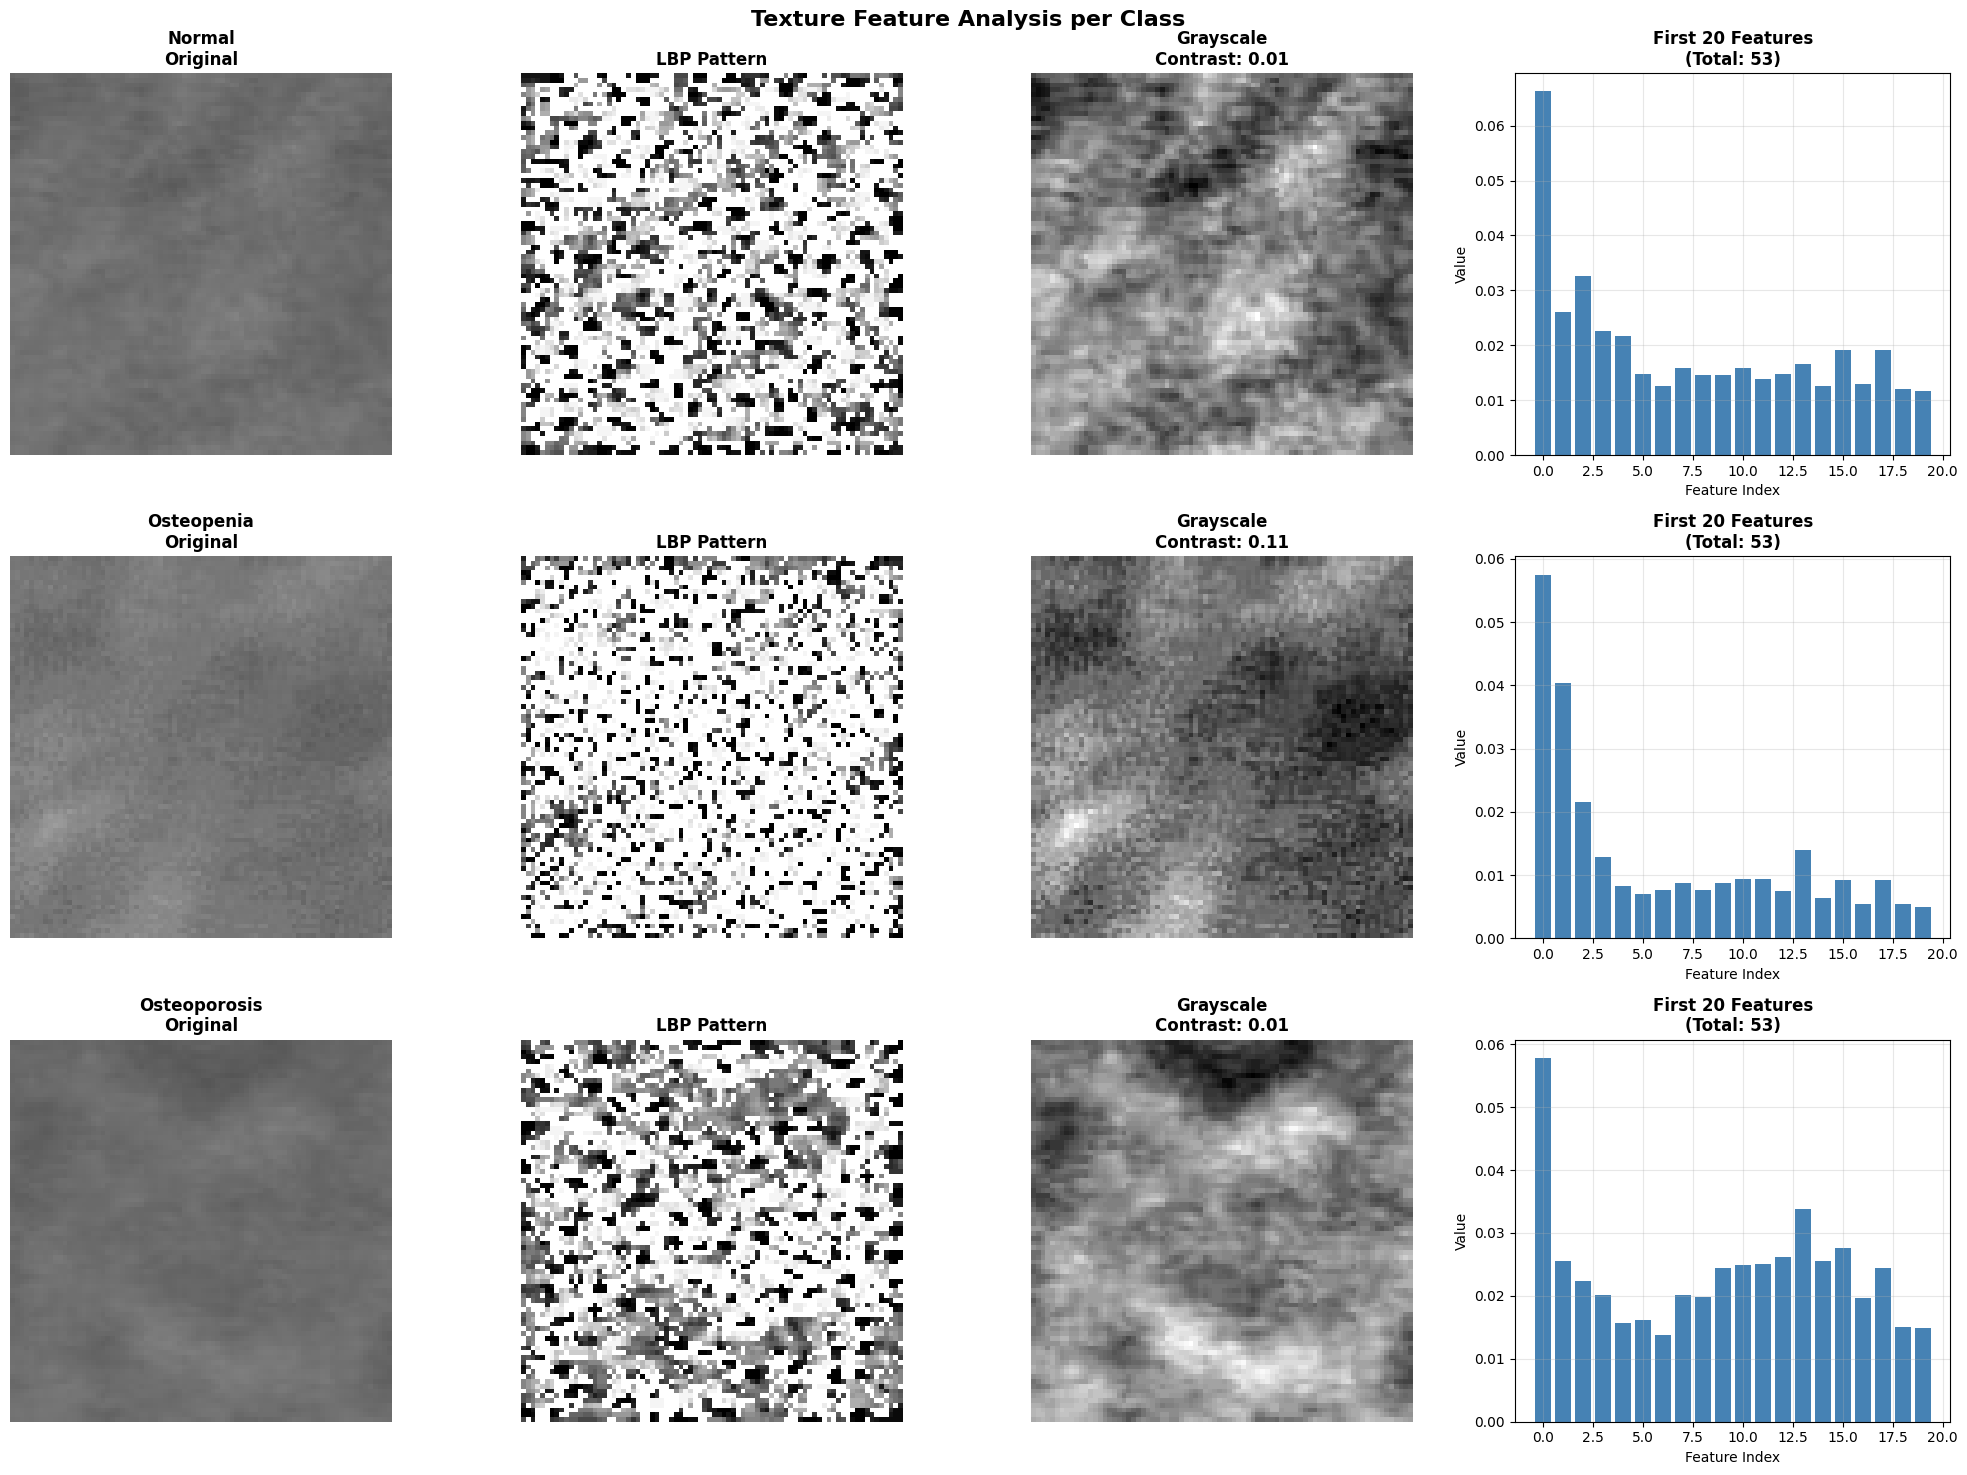


Texture Feature Dimensions:
  LBP features: 29
  GLCM features: 24
  Total: 53


In [6]:
class TextureFeatureExtractor:
    """Extract handcrafted texture features for bone analysis"""
    
    @staticmethod
    def extract_lbp_features(image, radius=3, n_points=24):
        """Extract Local Binary Pattern features"""
        gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
        lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
        
        # Calculate histogram of LBP
        n_bins = n_points + 2
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
        
        # Additional LBP statistics
        lbp_mean = np.mean(lbp)
        lbp_std = np.std(lbp)
        lbp_energy = np.sum(hist ** 2)
        
        return np.concatenate([hist, [lbp_mean, lbp_std, lbp_energy]])
    
    @staticmethod
    def extract_glcm_features(image, distances=[1, 3, 5], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
        """Extract Gray Level Co-occurrence Matrix features"""
        gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
        
        # Normalize to 0-255 and quantize to reduce computation
        gray = ((gray - gray.min()) / (gray.max() - gray.min()) * 255).astype(np.uint8)
        gray = (gray // 32)  # Quantize to 8 levels
        
        # Compute GLCM
        glcm = graycomatrix(gray, distances=distances, angles=angles, 
                           levels=8, symmetric=True, normed=True)
        
        # Extract Haralick features
        features = []
        for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']:
            values = graycoprops(glcm, prop).flatten()
            features.extend([np.mean(values), np.std(values), np.max(values), np.min(values)])
        
        return np.array(features)
    
    @staticmethod
    def extract_all_features(image):
        """Extract all texture features"""
        lbp_features = TextureFeatureExtractor.extract_lbp_features(image)
        glcm_features = TextureFeatureExtractor.extract_glcm_features(image)
        
        # Combine features
        all_features = np.concatenate([lbp_features, glcm_features])
        return all_features
    
    @staticmethod
    def get_feature_dim():
        """Get total feature dimension"""
        # LBP: (24+2) histogram bins + 3 statistics = 29
        # GLCM: 6 properties × 4 statistics = 24
        return 29 + 24  # Total: 53 features

# Visualize texture features
if not df.empty:
    print("\nExtracting Texture Features from Sample Images...")
    print("="*60)
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    fig.suptitle('Texture Feature Analysis per Class', fontsize=16, fontweight='bold')
    
    texture_extractor = TextureFeatureExtractor()
    
    for i, class_name in enumerate(CONFIG['class_names']):
        sample_path = df[df['label'] == class_name].iloc[0]['filepath']
        img = Image.open(sample_path).convert('RGB')
        img_np = np.array(img)
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        
        # Original image
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'{class_name}\nOriginal', fontweight='bold')
        axes[i, 0].axis('off')
        
        # LBP visualization
        lbp = local_binary_pattern(gray, 24, 3, method='uniform')
        axes[i, 1].imshow(lbp, cmap='gray')
        axes[i, 1].set_title('LBP Pattern', fontweight='bold')
        axes[i, 1].axis('off')
        
        # GLCM-based texture
        glcm = graycomatrix(gray // 32, distances=[1], angles=[0], 
                           levels=8, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
        
        axes[i, 2].imshow(gray, cmap='gray')
        axes[i, 2].set_title(f'Grayscale\nContrast: {contrast:.2f}', fontweight='bold')
        axes[i, 2].axis('off')
        
        # Feature histogram
        features = texture_extractor.extract_all_features(img)
        axes[i, 3].bar(range(len(features[:20])), features[:20], color='steelblue')
        axes[i, 3].set_title(f'First 20 Features\n(Total: {len(features)})', fontweight='bold')
        axes[i, 3].set_xlabel('Feature Index')
        axes[i, 3].set_ylabel('Value')
        axes[i, 3].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{CONFIG['save_dir']}/texture_features_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nTexture Feature Dimensions:")
    print(f"  LBP features: 29")
    print(f"  GLCM features: 24")
    print(f"  Total: {texture_extractor.get_feature_dim()}")
    print("="*60)

## 5. Visualize Preprocessing Effects

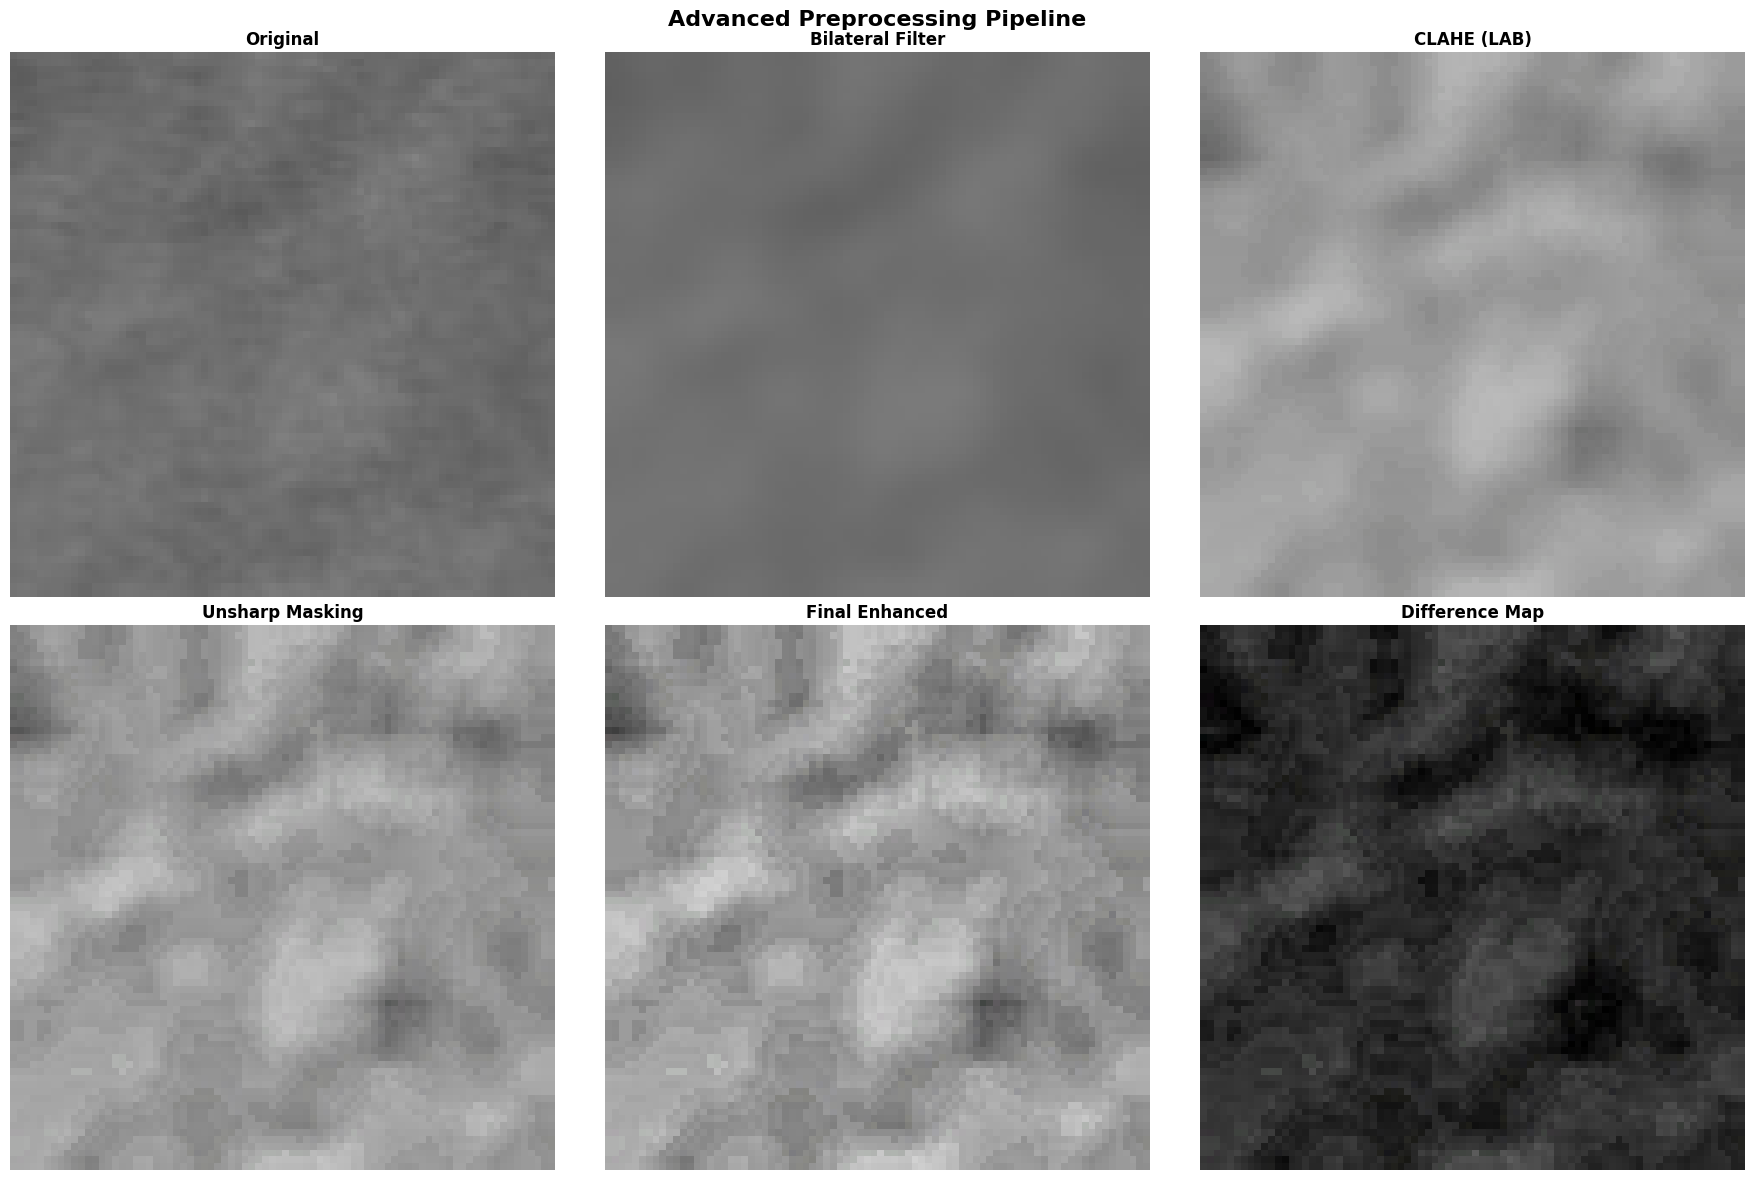

Preprocessing Effects:
  - Reduced noise while preserving edges
  - Enhanced bone structure visibility
  - Better contrast for trabecular patterns
  - Sharper details for classification


In [7]:
# Visualize preprocessing pipeline
if not df.empty:
    sample_path = df[df['split'] == 'train'].iloc[0]['filepath']
    original_img = Image.open(sample_path).convert('RGB')
    
    preprocess = AdvancedPreprocessing()
    
    # Apply each step
    bilateral = preprocess.bilateral_filter(original_img)
    clahe_lab = preprocess.apply_clahe_lab(bilateral)
    unsharp = preprocess.unsharp_mask(clahe_lab)
    enhanced = preprocess.enhance_contrast(unsharp)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Advanced Preprocessing Pipeline', fontsize=16, fontweight='bold')
    
    axes[0, 0].imshow(original_img)
    axes[0, 0].set_title('Original', fontweight='bold', fontsize=12)
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(bilateral)
    axes[0, 1].set_title('Bilateral Filter', fontweight='bold', fontsize=12)
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(clahe_lab)
    axes[0, 2].set_title('CLAHE (LAB)', fontweight='bold', fontsize=12)
    axes[0, 2].axis('off')
    
    axes[1, 0].imshow(unsharp)
    axes[1, 0].set_title('Unsharp Masking', fontweight='bold', fontsize=12)
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(enhanced)
    axes[1, 1].set_title('Final Enhanced', fontweight='bold', fontsize=12)
    axes[1, 1].axis('off')
    
    # Show difference
    diff = np.abs(np.array(enhanced).astype(float) - np.array(original_img).astype(float))
    axes[1, 2].imshow(diff.astype(np.uint8))
    axes[1, 2].set_title('Difference Map', fontweight='bold', fontsize=12)
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{CONFIG['save_dir']}/preprocessing_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Preprocessing Effects:")
    print("  - Reduced noise while preserving edges")
    print("  - Enhanced bone structure visibility")
    print("  - Better contrast for trabecular patterns")
    print("  - Sharper details for classification")

## 6. Data Augmentation with MixUp

In [8]:
# Enhanced training transforms with preprocessing
train_transform = transforms.Compose([
    PreprocessTransform(apply_advanced=True),  # Advanced preprocessing
    transforms.Resize(CONFIG['img_size']),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomResizedCrop(CONFIG['img_size'][0], scale=(0.85, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))  # Random erasing
])

val_transform = transforms.Compose([
    PreprocessTransform(apply_advanced=True),  # Advanced preprocessing
    transforms.Resize(CONFIG['img_size']),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def mixup_data(x, y, alpha=0.2):
    """Apply MixUp augmentation"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """MixUp loss"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print("Augmentation Strategy:")
print("="*60)
print("- Advanced preprocessing pipeline")
print("- Geometric: Random rotation, horizontal flip, resized crop")
print("- Photometric: Color jitter (brightness, contrast, saturation)")
print("- Regularization: Random erasing")
print(f"- MixUp augmentation (alpha={CONFIG['mixup_alpha']})")
print("="*60)

Augmentation Strategy:
- Advanced preprocessing pipeline
- Geometric: Random rotation, horizontal flip, resized crop
- Photometric: Color jitter (brightness, contrast, saturation)
- Regularization: Random erasing
- MixUp augmentation (alpha=0.2)


## 7. Dataset with Weighted Sampling

In [9]:
class OsteoporosisDataset(Dataset):
    """Custom dataset for osteoporosis classification with texture features"""

    def __init__(self, dataframe, transform=None, extract_texture=False):
        self.df = dataframe
        self.transform = transform
        self.extract_texture = extract_texture
        if extract_texture:
            self.texture_extractor = TextureFeatureExtractor()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['filepath']
        label = row['label_idx']

        # Load image
        img = Image.open(img_path).convert('RGB')

        # Extract texture features before transformation (on preprocessed image)
        texture_features = None
        if self.extract_texture:
            preprocess = PreprocessTransform(apply_advanced=True)
            preprocessed_img = preprocess(img)
            texture_features = self.texture_extractor.extract_all_features(preprocessed_img)
            texture_features = torch.FloatTensor(texture_features)

        # Apply transformation
        if self.transform:
            img = self.transform(img)

        if texture_features is not None:
            return img, label, texture_features
        return img, label

required_cols = {'filepath', 'label', 'split', 'label_idx'}
missing_cols = sorted(required_cols - set(df.columns))
if missing_cols:
    raise ValueError(
        f"Dataset DataFrame is missing columns: {missing_cols}. "
        f"Please verify data loading and CONFIG['data_dir']={CONFIG['data_dir']}"
    )
if df.empty:
    raise ValueError(
        f"No data found under CONFIG['data_dir']={CONFIG['data_dir']}. "
        "Please check dataset path and folder structure."
    )

# Create datasets
train_df = df[df['split'] == 'train'].reset_index(drop=True)
valid_df = df[df['split'] == 'valid'].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)

print("\nCreating datasets...")
print(f"  Train: {len(train_df):,} samples")
print(f"  Valid: {len(valid_df):,} samples")
print(f"  Test:  {len(test_df):,} samples")

use_texture = CONFIG.get('use_texture_features', False)

train_dataset = OsteoporosisDataset(train_df, transform=train_transform, extract_texture=use_texture)
valid_dataset = OsteoporosisDataset(valid_df, transform=val_transform, extract_texture=use_texture)
test_dataset = OsteoporosisDataset(test_df, transform=val_transform, extract_texture=use_texture)

# Weighted sampler for balanced training
if CONFIG.get('use_weighted_sampler', False) and not use_texture:
    class_counts = train_df['label_idx'].value_counts().sort_index().values
    class_weights = 1.0 / class_counts
    sample_weights = np.array([class_weights[label] for label in train_df['label_idx']])
    sample_weights = torch.from_numpy(sample_weights).double()
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG['batch_size'],
        sampler=sampler,
        num_workers=2,
        pin_memory=True
    )
    print("\nUsing WeightedRandomSampler for balanced batch sampling")
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

valid_loader = DataLoader(
    valid_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\nDataLoader Configuration:")
print(f"  Batch size: {CONFIG['batch_size']}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Valid batches: {len(valid_loader)}")
print(f"  Test batches:  {len(test_loader)}")
print(f"  Texture features: {use_texture}")


Creating datasets...
  Train: 76,921 samples
  Valid: 9,607 samples
  Test:  9,594 samples

DataLoader Configuration:
  Batch size: 64
  Train batches: 1202
  Valid batches: 151
  Test batches:  150
  Texture features: True


## 8. Model Architecture

This section defines the neural network architecture for osteoporosis classification. The model incorporates residual connections and attention mechanisms to improve feature learning and focus on relevant bone regions.

**Convolutional Block Attention Module (CBAM):**

CBAM sequentially applies channel and spatial attention to refine feature maps:
- **Channel Attention**: Learns which feature channels contain the most relevant information for classification
- **Spatial Attention**: Identifies which spatial locations in the feature map are most important
- Applied after each residual block to enhance feature discrimination

**Model Components:**

1. **ResidualBlockWithCBAM**: Implements residual learning with optional CBAM attention
2. **ImprovedCNN**: Custom CNN with 4 residual layers, progressively increasing feature channels (64 → 128 → 256 → 512)
3. **HybridModel**: Combines CNN features with handcrafted texture features through a fusion layer

The architecture uses adaptive average pooling for spatial dimension reduction and includes dropout regularization to prevent overfitting.

In [10]:
class ChannelAttention(nn.Module):
    """Channel Attention Module"""
    def __init__(self, channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    """Spatial Attention Module"""
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)
        return self.sigmoid(x)

class CBAM(nn.Module):
    """Convolutional Block Attention Module"""
    def __init__(self, channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)
    
    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x

class ResidualBlockWithCBAM(nn.Module):
    """Residual block with CBAM attention"""
    def __init__(self, in_channels, out_channels, stride=1, use_cbam=True):
        super(ResidualBlockWithCBAM, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.cbam = CBAM(out_channels) if use_cbam else nn.Identity()
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.cbam(out)  # Apply CBAM attention
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ImprovedCNN(nn.Module):
    """Improved Custom CNN with CBAM attention and residual connections"""
    
    def __init__(self, num_classes=3, dropout=0.5, use_cbam=True):
        super(ImprovedCNN, self).__init__()
        self.use_cbam = use_cbam
        
        # Initial convolution
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        # Residual blocks with CBAM
        self.layer1 = self._make_layer(64, 64, 2, use_cbam=use_cbam)
        self.layer2 = self._make_layer(64, 128, 2, stride=2, use_cbam=use_cbam)
        self.layer3 = self._make_layer(128, 256, 2, stride=2, use_cbam=use_cbam)
        self.layer4 = self._make_layer(256, 512, 2, stride=2, use_cbam=use_cbam)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout * 0.7),
            nn.Linear(256, num_classes)
        )
    
    def _make_layer(self, in_channels, out_channels, num_blocks, stride=1, use_cbam=True):
        layers = []
        layers.append(ResidualBlockWithCBAM(in_channels, out_channels, stride, use_cbam))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlockWithCBAM(out_channels, out_channels, 1, use_cbam))
        return nn.Sequential(*layers)
    
    def forward(self, x, return_features=False):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        if return_features:
            features = x  # Save for Grad-CAM
        
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        
        if return_features:
            return x, features
        return x

class HybridModel(nn.Module):
    """Hybrid model combining CNN + handcrafted texture features"""
    
    def __init__(self, num_classes=3, dropout=0.5, use_cbam=True, use_texture=True):
        super(HybridModel, self).__init__()
        self.use_texture = use_texture
        
        # CNN backbone
        self.cnn = ImprovedCNN(num_classes=num_classes, dropout=dropout, use_cbam=use_cbam)
        
        if use_texture:
            # Texture feature branch
            texture_dim = TextureFeatureExtractor.get_feature_dim()
            self.texture_fc = nn.Sequential(
                nn.Linear(texture_dim, 128),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(128),
                nn.Dropout(0.3),
                nn.Linear(128, 64),
                nn.ReLU(inplace=True)
            )
            
            # Fusion layer
            self.cnn.classifier = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(512, 256),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(256)
            )
            
            self.fusion = nn.Sequential(
                nn.Dropout(dropout * 0.7),
                nn.Linear(256 + 64, 128),  # CNN features + texture features
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(128),
                nn.Dropout(dropout * 0.5),
                nn.Linear(128, num_classes)
            )
    
    def forward(self, x, texture_features=None):
        # CNN features
        cnn_out = self.cnn(x)
        
        if self.use_texture and texture_features is not None:
            # Texture features
            texture_out = self.texture_fc(texture_features)
            
            # Concatenate and fuse
            combined = torch.cat([cnn_out, texture_out], dim=1)
            out = self.fusion(combined)
            return out
        else:
            # If no texture features, add final classification layer
            if hasattr(self, 'fusion'):
                out = self.fusion(torch.cat([cnn_out, torch.zeros(cnn_out.size(0), 64).to(cnn_out.device)], dim=1))
                return out
            return cnn_out

# Initialize model based on config
if CONFIG.get('use_texture_features', False):
    print("\nInitializing Hybrid Model (CNN + Texture Features)...")
    model = HybridModel(
        num_classes=CONFIG['num_classes'],
        dropout=CONFIG['dropout_rate'],
        use_cbam=CONFIG.get('use_cbam', True),
        use_texture=True
    ).to(device)
    model_type = "Hybrid (CNN + Texture)"
else:
    print("\nInitializing CNN with CBAM Attention...")
    model = ImprovedCNN(
        num_classes=CONFIG['num_classes'],
        dropout=CONFIG['dropout_rate'],
        use_cbam=CONFIG.get('use_cbam', True)
    ).to(device)
    model_type = "CNN with CBAM"

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nModel Architecture Summary:")
print("="*60)
print(f"  Model type: {model_type}")
print(f"  Total parameters: {count_parameters(model):,}")
print(f"  Input size: {CONFIG['img_size']}")
print(f"  Output classes: {CONFIG['num_classes']}")
print(f"  Device: {device}")
print("\nArchitecture Features:")
print("  - Residual connections for gradient flow")
if CONFIG.get('use_cbam', True):
    print("  - CBAM attention (channel + spatial)")
if CONFIG.get('use_texture_features', False):
    print("  - Hybrid architecture (512 CNN + 53 texture features)")
    print("  - Feature fusion layer")
print("  - Adaptive average pooling")
print("  - 4 layers with 8 residual blocks")
print("  - Batch normalization and dropout regularization")
print("="*60)


Initializing Hybrid Model (CNN + Texture Features)...

Model Architecture Summary:
  Model type: Hybrid (CNN + Texture)
  Total parameters: 11,458,131
  Input size: (224, 224)
  Output classes: 3
  Device: cuda

Architecture Features:
  - Residual connections for gradient flow
  - CBAM attention (channel + spatial)
  - Hybrid architecture (512 CNN + 53 texture features)
  - Feature fusion layer
  - Adaptive average pooling
  - 4 layers with 8 residual blocks
  - Batch normalization and dropout regularization


## 9. Training Setup with OneCycleLR

In [11]:
# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Calculate class weights
train_df = df[df['split'] == 'train']
class_counts = np.array([
    len(train_df[train_df['label'] == cls]) for cls in CONFIG['class_names']
])
weights = 1.0 / class_counts
weights = weights / weights.sum() * len(weights)
class_weights = torch.FloatTensor(weights).to(device)

criterion = FocalLoss(alpha=class_weights, gamma=2)

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay'],
    betas=(0.9, 0.999)
)

# OneCycleLR scheduler (better than ReduceLROnPlateau)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CONFIG['learning_rate'],
    epochs=CONFIG['epochs'],
    steps_per_epoch=len(train_loader),
    pct_start=0.3,  # 30% warmup
    anneal_strategy='cos'
)

print("\nTraining Configuration:")
print("="*60)
print(f"  Loss: Focal Loss (gamma=2)")
print(f"  Class weights: {[f'{w:.2f}' for w in class_weights.cpu().numpy()]}")
print(f"  Optimizer: AdamW")
print(f"  Learning rate: {CONFIG['learning_rate']}")
print(f"  Weight decay: {CONFIG['weight_decay']}")
print(f"  LR Scheduler: OneCycleLR (30% warmup, cosine annealing)")
print(f"  Epochs: {CONFIG['epochs']}")
print(f"  MixUp alpha: {CONFIG['mixup_alpha']}")
print(f"  Early stopping patience: {CONFIG['patience']}")
print("="*60)


Training Configuration:
  Loss: Focal Loss (gamma=2)
  Class weights: ['1.33', '0.67', '1.00']
  Optimizer: AdamW
  Learning rate: 0.001
  Weight decay: 0.01
  LR Scheduler: OneCycleLR (30% warmup, cosine annealing)
  Epochs: 20
  MixUp alpha: 0.2
  Early stopping patience: 7


## 10. Training Loop with MixUp

In [12]:
from pathlib import Path

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'learning_rates': []
}

best_val_acc = 0.0
patience_counter = 0
best_model_wts = None

checkpoint_path = Path(CONFIG["model_dir"]) / "best_improved_model.pth"


def evaluate_validation_accuracy(model):
    """Compute validation accuracy over the current validation loader."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in valid_loader:
            if CONFIG.get('use_texture_features', False):
                images, labels, texture_features = batch
                texture_features = texture_features.to(device)
            else:
                images, labels = batch
                texture_features = None
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images, texture_features)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    if total == 0:
        return 0.0
    return 100.0 * correct / total


if checkpoint_path.exists():
    print(f"Checkpoint found at {checkpoint_path}. Loading and skipping training...")
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    best_model_wts = model.state_dict().copy()

    metadata_path = Path(CONFIG["model_dir"]) / "improved_model_complete.pth"
    if metadata_path.exists():
        metadata = torch.load(metadata_path, map_location='cpu')
        best_val_acc = float(metadata.get('best_val_acc', 0.0) or 0.0)
        print(f"Recovered best validation accuracy from metadata: {best_val_acc:.2f}%")
    else:
        best_val_acc = evaluate_validation_accuracy(model)
        print(f"Computed validation accuracy from loader: {best_val_acc:.2f}%")
else:
    print("\nStarting Training...")
    print("="*60)

    for epoch in range(CONFIG['epochs']):
        print(f'\nEpoch {epoch+1}/{CONFIG["epochs"]}')
        print('-' * 60)

        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_pbar = tqdm(train_loader, desc='Training')
        for batch in train_pbar:
            # Handle texture features if enabled
            if CONFIG.get('use_texture_features', False):
                images, labels, texture_features = batch
                texture_features = texture_features.to(device)
            else:
                images, labels = batch
                texture_features = None

            images, labels = images.to(device), labels.to(device)

            # Apply MixUp
            if CONFIG['mixup_alpha'] > 0 and np.random.rand() > 0.5:
                images, targets_a, targets_b, lam = mixup_data(images, labels, CONFIG['mixup_alpha'])

                optimizer.zero_grad()
                outputs = model(images, texture_features)
                loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            else:
                optimizer.zero_grad()
                outputs = model(images, texture_features)
                loss = criterion(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()  # OneCycleLR updates every batch

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            train_pbar.set_postfix({
                'loss': f'{train_loss/(train_pbar.n+1):.4f}',
                'acc': f'{100.*train_correct/train_total:.2f}%'
            })

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            val_pbar = tqdm(valid_loader, desc='Validation')
            for batch in val_pbar:
                # Handle texture features if enabled
                if CONFIG.get('use_texture_features', False):
                    images, labels, texture_features = batch
                    texture_features = texture_features.to(device)
                else:
                    images, labels = batch
                    texture_features = None

                images, labels = images.to(device), labels.to(device)

                outputs = model(images, texture_features)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                val_pbar.set_postfix({
                    'loss': f'{val_loss/(val_pbar.n+1):.4f}',
                    'acc': f'{100.*val_correct/val_total:.2f}%'
                })

        # Calculate metrics
        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = 100. * train_correct / train_total
        epoch_val_loss = val_loss / len(valid_loader)
        epoch_val_acc = 100. * val_correct / val_total
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        history['learning_rates'].append(current_lr)

        print(f'\nEpoch {epoch+1} Summary:')
        print(f'  Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%')
        print(f'  Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%')
        print(f'  Learning Rate: {current_lr:.6f}')

        # Model checkpointing
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_wts = model.state_dict().copy()
            torch.save(model.state_dict(), f'{CONFIG["model_dir"]}/best_improved_model.pth')
            print(f'  Model saved (Best val acc: {best_val_acc:.2f}%)')
            patience_counter = 0
        else:
            patience_counter += 1
            print(f'  No improvement (patience: {patience_counter}/{CONFIG["patience"]})')

            if patience_counter >= CONFIG['patience']:
                print(f'\nEarly stopping triggered after {epoch+1} epochs')
                break

# Load best model
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)

print('\n' + '='*60)
print('Training Completed or Skipped')
if checkpoint_path.exists():
    print('Loaded existing checkpoint; training skipped.')
else:
    print(f'Best Validation Accuracy: {best_val_acc:.2f}%')
print('='*60)

Checkpoint found at models_improved/best_improved_model.pth. Loading and skipping training...
Computed validation accuracy from loader: 98.65%

Training Completed or Skipped
Loaded existing checkpoint; training skipped.


## 11. Training History

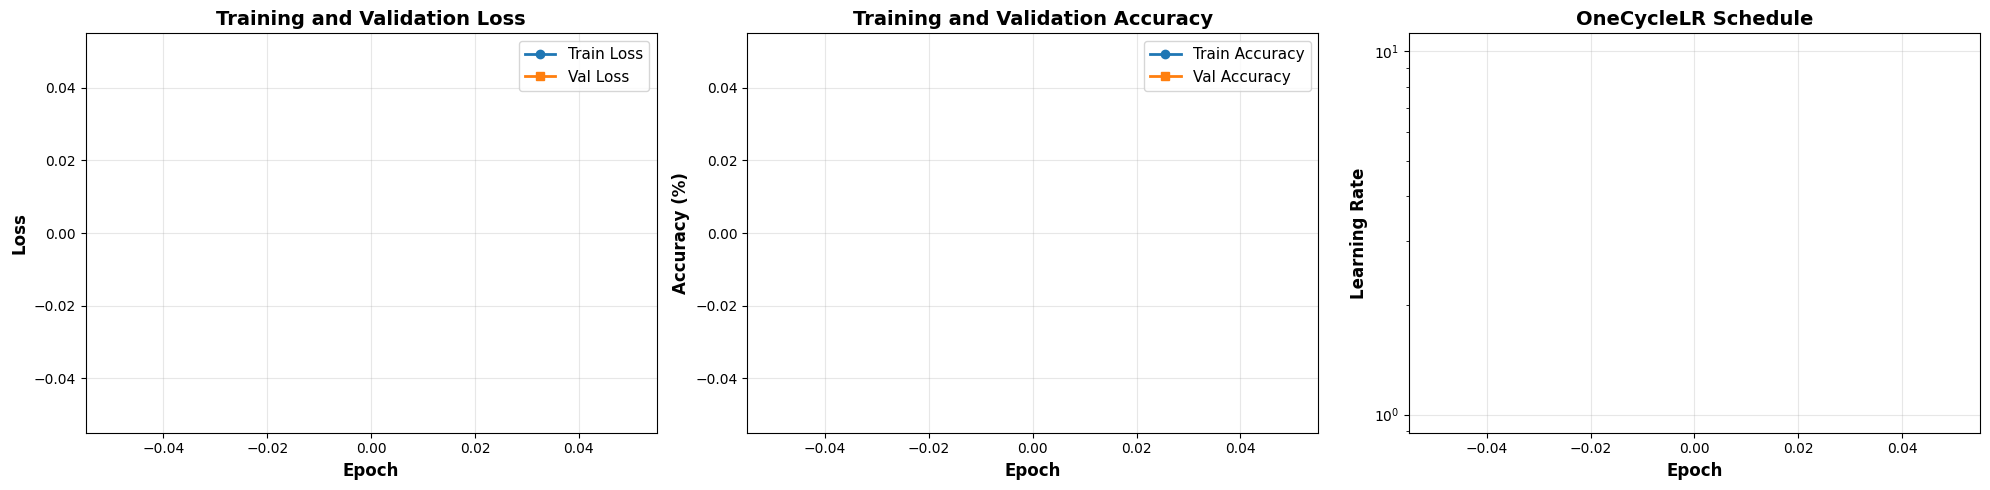

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['learning_rates'], marker='o', linewidth=2, color='green')
axes[2].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
axes[2].set_title('OneCycleLR Schedule', fontsize=14, fontweight='bold')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CONFIG["save_dir"]}/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Test Set Evaluation

In [14]:
model.eval()
all_labels = []
all_preds = []
all_probs = []

print("Evaluating on test set...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        # Handle texture features if enabled
        if CONFIG.get('use_texture_features', False):
            images, labels, texture_features = batch
            texture_features = texture_features.to(device)
        else:
            images, labels = batch
            texture_features = None
        
        images, labels = images.to(device), labels.to(device)
        outputs = model(images, texture_features)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

test_accuracy = accuracy_score(all_labels, all_preds)

print("\n" + "="*60)
print("TEST SET EVALUATION RESULTS")
print("="*60)
print(f"Overall Accuracy: {test_accuracy*100:.2f}%")
print("="*60)

print("\nDETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    all_labels,
    all_preds,
    target_names=CONFIG['class_names'],
    digits=4
))

print("\nPer-Class Performance:")
print("="*60)
for i, class_name in enumerate(CONFIG['class_names']):
    class_mask = all_labels == i
    class_acc = (all_preds[class_mask] == all_labels[class_mask]).mean() * 100
    class_count = class_mask.sum()
    print(f"  {class_name:15s}: {class_acc:6.2f}% ({class_count:,} samples)")
print("="*60)

Evaluating on test set...


Testing:   0%|          | 0/150 [00:00<?, ?it/s]


TEST SET EVALUATION RESULTS
Overall Accuracy: 91.56%

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal     0.9279    0.7556    0.8330      2214
  Osteopenia     0.8728    0.9670    0.9175      4428
Osteoporosis     0.9806    0.9583    0.9693      2952

    accuracy                         0.9156      9594
   macro avg     0.9271    0.8937    0.9066      9594
weighted avg     0.9187    0.9156    0.9139      9594


Per-Class Performance:
  Normal         :  75.56% (2,214 samples)
  Osteopenia     :  96.70% (4,428 samples)
  Osteoporosis   :  95.83% (2,952 samples)


## 13. Confusion Matrix & ROC Curves

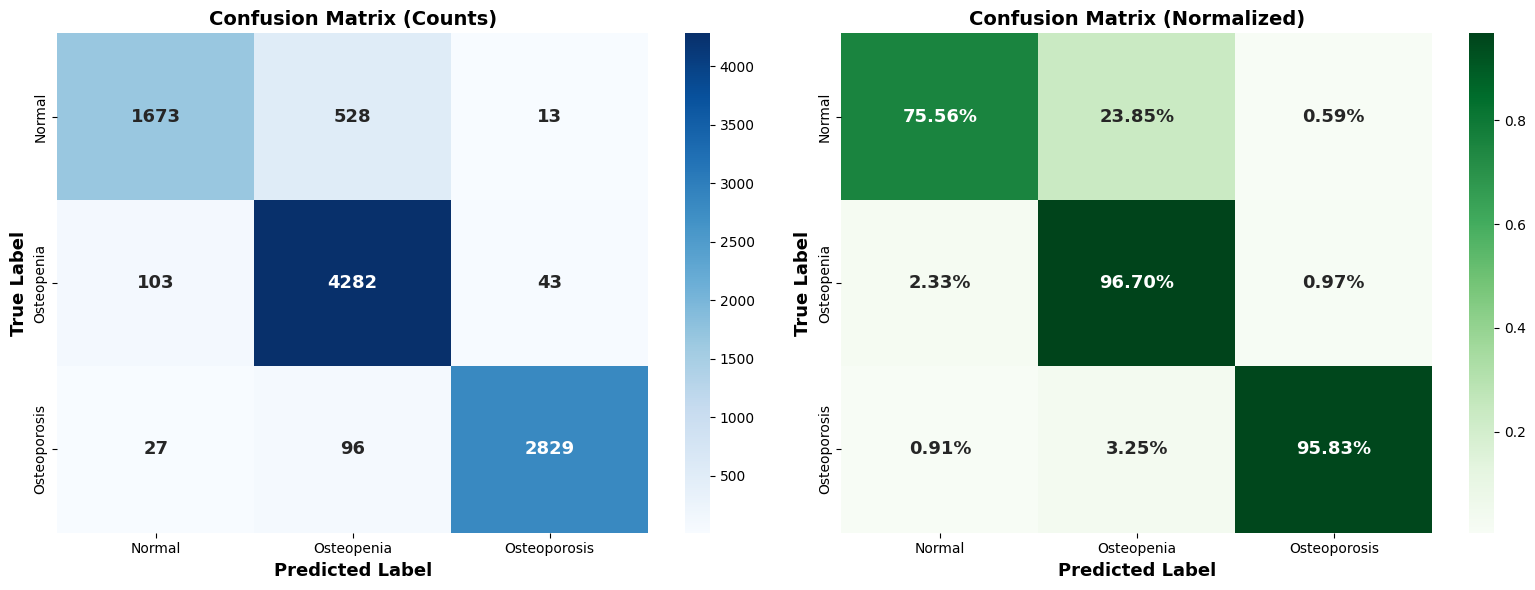

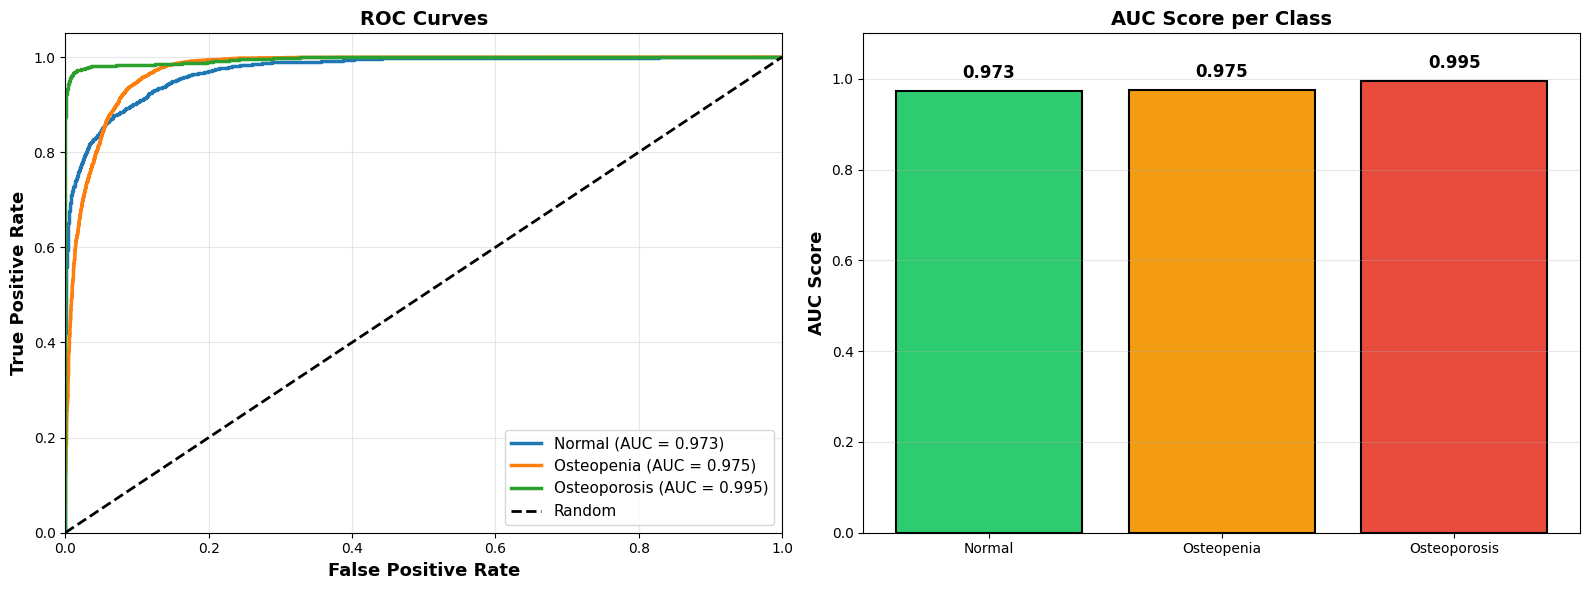


ROC-AUC Scores:
  Normal         : 0.9731
  Osteopenia     : 0.9749
  Osteoporosis   : 0.9954
  Mean AUC:        0.9811


In [15]:
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CONFIG['class_names'],
            yticklabels=CONFIG['class_names'],
            ax=axes[0],
            annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=CONFIG['class_names'],
            yticklabels=CONFIG['class_names'],
            ax=axes[1],
            annot_kws={'size': 13, 'weight': 'bold'})
axes[1].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{CONFIG["save_dir"]}/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC Curves
y_test_bin = label_binarize(all_labels, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

auc_scores = []
for i in range(CONFIG['num_classes']):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    axes[0].plot(fpr, tpr, lw=2.5, label=f'{CONFIG["class_names"][i]} (AUC = {roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
axes[0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)

colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[1].bar(CONFIG['class_names'], auc_scores, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('AUC Score', fontsize=13, fontweight='bold')
axes[1].set_title('AUC Score per Class', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1.1])
axes[1].grid(axis='y', alpha=0.3)

for bar, score in zip(bars, auc_scores):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(f'{CONFIG["save_dir"]}/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nROC-AUC Scores:")
print("="*60)
for i, class_name in enumerate(CONFIG['class_names']):
    print(f"  {class_name:15s}: {auc_scores[i]:.4f}")
print(f"  Mean AUC:        {np.mean(auc_scores):.4f}")
print("="*60)

## 16. Ordinal-Aware Learning (CORAL — Severity-Aware Classification)

In osteoporosis detection, the three diagnostic classes follow a natural clinical severity ordering:

**Normal (0) → Osteopenia (1) → Osteoporosis (2)**

Standard classification approaches (softmax + cross-entropy) treat these as unrelated categories, ignoring this ordinal structure. This means the model considers misclassifying a "Normal" patient as "Osteoporosis" equally costly as misclassifying them as "Osteopenia" — which is clinically inappropriate, since the former represents a much more severe diagnostic error.

### What is CORAL?

**CORAL (COnsistent RAnk Logits)** is an ordinal regression framework that:

1. **Models cumulative probabilities** instead of class probabilities: P(Y > k) for each threshold k
2. **Uses weight-sharing** across ordinal tasks with individual bias terms, ensuring rank consistency
3. **Preserves the ordinal structure** of the label space, so the model learns that class transitions are meaningful

### Expected Improvement

By incorporating ordinal awareness, we expect:
- **Reduction in "extreme" misclassifications**: Fewer cases where Normal is predicted as Osteoporosis (or vice versa)
- **Clinically safer predictions**: When the model is wrong, it tends to predict adjacent classes rather than the opposite extreme
- **Smoother probability transitions**: The cumulative probability formulation naturally enforces monotonicity across severity levels

In [16]:
# Ordinal-Aware Learning with CORAL (offline-friendly, no external pip)

from pathlib import Path
import torch.nn.functional as F

# Minimal CORAL components implemented locally (no coral-pytorch dependency)
def coral_target(labels, num_classes):
    """Create CORAL target matrix of shape (batch, num_classes-1)."""
    device = labels.device
    batch_size = labels.size(0)
    targets = torch.zeros((batch_size, num_classes - 1), device=device)
    for k in range(num_classes - 1):
        targets[:, k] = (labels > k).float()
    return targets

class CoralLoss(nn.Module):
    def forward(self, logits, labels):
        # logits: (batch, K-1), labels: (batch,)
        num_classes = logits.size(1) + 1
        targets = coral_target(labels, num_classes)
        return F.binary_cross_entropy_with_logits(logits, targets)

def corn_label_from_logits(logits):
    """Decode CORAL logits to class labels by counting cumulative probs > 0.5."""
    probs = torch.sigmoid(logits)
    return torch.sum(probs > 0.5, dim=1)

CORAL_AVAILABLE = True
print("Using built-in CORAL loss/decoder (no internet required)\n")

# If a saved ordinal checkpoint exists, load and skip training; otherwise train
import copy

# Define OrdinalHybridModel
class OrdinalHybridModel(nn.Module):
    """
    Ordinal version of HybridModel using CORAL framework.
    Replaces the final classification layer to output (num_classes - 1) logits
    representing cumulative probabilities P(Y > k) for ordinal regression.
    """
    
    def __init__(self, num_classes=3, dropout=0.5, use_cbam=True, use_texture=True):
        super(OrdinalHybridModel, self).__init__()
        self.use_texture = use_texture
        self.num_classes = num_classes
        
        # CNN backbone (same as HybridModel)
        self.cnn = ImprovedCNN(num_classes=num_classes, dropout=dropout, use_cbam=use_cbam)
        
        if use_texture:
            # Texture feature branch (identical to HybridModel)
            texture_dim = TextureFeatureExtractor.get_feature_dim()
            self.texture_fc = nn.Sequential(
                nn.Linear(texture_dim, 128),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(128),
                nn.Dropout(0.3),
                nn.Linear(128, 64),
                nn.ReLU(inplace=True)
            )
            
            # CNN classifier outputs 256 features (same as HybridModel)
            self.cnn.classifier = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(512, 256),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(256)
            )
            
            # CORAL fusion layer: outputs (num_classes - 1) logits instead of num_classes
            self.fusion = nn.Sequential(
                nn.Dropout(dropout * 0.7),
                nn.Linear(256 + 64, 128),  # CNN features + texture features
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(128),
                nn.Dropout(dropout * 0.5),
                nn.Linear(128, num_classes - 1)  # CORAL: K-1 output neurons
            )
        else:
            # Without texture: modify the classifier to output num_classes - 1
            self.cnn.classifier = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(512, 256),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(256),
                nn.Dropout(dropout * 0.7),
                nn.Linear(256, num_classes - 1)  # CORAL: K-1 output neurons
            )
    
    def forward(self, x, texture_features=None):
        # CNN features
        cnn_out = self.cnn(x)
        
        if self.use_texture and texture_features is not None:
            # Texture features
            texture_out = self.texture_fc(texture_features)
            
            # Concatenate and fuse
            combined = torch.cat([cnn_out, texture_out], dim=1)
            out = self.fusion(combined)
            return out
        else:
            if hasattr(self, 'fusion'):
                out = self.fusion(torch.cat([cnn_out, torch.zeros(cnn_out.size(0), 64).to(cnn_out.device)], dim=1))
                return out
            return cnn_out

print("OrdinalHybridModel defined")
print(f"   Output logits: {CONFIG['num_classes'] - 1} (for {CONFIG['num_classes']} ordinal classes)")
print("\n")

# If a saved ordinal checkpoint exists, load and skip training
ordinal_ckpt_candidates = [
    Path('models_improved') / 'ordinal_model_best.pth',
    Path(CONFIG['model_dir']) / 'ordinal_model_best.pth',
    Path('/kaggle/working/models_improved/ordinal_model_best.pth'),
    Path('/kaggle/input/datasets/sathishkesavannnn/best-model/ordinal_model_best.pth')
]
ordinal_ckpt_path = next((p for p in ordinal_ckpt_candidates if p.exists()), None)
if ordinal_ckpt_path is not None:
    print(f"Found ordinal checkpoint at {ordinal_ckpt_path}. Loading and skipping ordinal training...\n")
    ordinal_model = OrdinalHybridModel(
        num_classes=CONFIG['num_classes'],
        dropout=CONFIG['dropout_rate'],
        use_cbam=CONFIG.get('use_cbam', True),
        use_texture=CONFIG.get('use_texture_features', True)
    ).to(device)
    ckpt = torch.load(ordinal_ckpt_path, map_location=device)
    ordinal_model.load_state_dict(ckpt['model_state_dict'])
    ordinal_model.eval()
    # Minimal evaluation to produce preds/probs
    ordinal_all_labels = []
    ordinal_all_logits = []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Ordinal Testing (loaded)'):
            if CONFIG.get('use_texture_features', False):
                images, labels, texture_features_batch = batch
                texture_features_batch = texture_features_batch.to(device)
            else:
                images, labels = batch
                texture_features_batch = None
            images, labels = images.to(device), labels.to(device)
            logits = ordinal_model(images, texture_features_batch)
            ordinal_all_labels.extend(labels.cpu().numpy())
            ordinal_all_logits.extend(logits.cpu().numpy())
    ordinal_all_labels = np.array(ordinal_all_labels)
    ordinal_all_logits = np.array(ordinal_all_logits)
    ordinal_preds = corn_label_from_logits(torch.tensor(ordinal_all_logits)).numpy()
    ordinal_cumprobs = torch.sigmoid(torch.tensor(ordinal_all_logits)).numpy()
    ordinal_probs = np.zeros((len(ordinal_cumprobs), CONFIG['num_classes']))
    ordinal_probs[:, 0] = 1 - ordinal_cumprobs[:, 0]
    for k in range(1, CONFIG['num_classes'] - 1):
        ordinal_probs[:, k] = ordinal_cumprobs[:, k-1] - ordinal_cumprobs[:, k]
    ordinal_probs[:, -1] = ordinal_cumprobs[:, -1]
    ordinal_probs = np.clip(ordinal_probs, 0, 1)
    ordinal_probs = ordinal_probs / ordinal_probs.sum(axis=1, keepdims=True)
    ordinal_test_accuracy = accuracy_score(ordinal_all_labels, ordinal_preds)
    print(f"Loaded ordinal model accuracy (test set): {ordinal_test_accuracy*100:.2f}%\n")
else:
    ordinal_ckpt_path = Path(CONFIG['model_dir']) / 'ordinal_model_best.pth'
    # Proceed with warm-start and training if no checkpoint
    ordinal_model = OrdinalHybridModel(
        num_classes=CONFIG['num_classes'],
        dropout=CONFIG['dropout_rate'],
        use_cbam=CONFIG.get('use_cbam', True),
        use_texture=CONFIG.get('use_texture_features', True)
    ).to(device)
    
    # Load weights from the trained model with strict=False
    trained_state_dict = model.state_dict()
    ordinal_state_dict = ordinal_model.state_dict()
    
    # Find matching and skipped layers
    loaded_keys = []
    skipped_keys = []
    
    for key in trained_state_dict:
        if key in ordinal_state_dict and trained_state_dict[key].shape == ordinal_state_dict[key].shape:
            ordinal_state_dict[key] = trained_state_dict[key]
            loaded_keys.append(key)
        else:
            skipped_keys.append(key)
    
    ordinal_model.load_state_dict(ordinal_state_dict)
    
    print(f"\n Warm Start Summary:")
    print(f"   Loaded layers: {len(loaded_keys)}")
    print(f"   Skipped layers (shape mismatch or new): {len(skipped_keys)}")
    if skipped_keys:
        print(f"   Skipped keys: {skipped_keys}")
    print("\n")
    
    # Fine-tune with CORAL loss
    coral_loss = CoralLoss()
    ordinal_optimizer = optim.AdamW(
        ordinal_model.parameters(),
        lr=1e-4,  # Fine-tuning learning rate
        weight_decay=CONFIG['weight_decay']
    )
    
    ordinal_epochs = 5
    ordinal_patience = 3
    ordinal_train_losses = []
    ordinal_val_losses = []
    
    best_ordinal_val_loss = float('inf')
    ordinal_patience_counter = 0
    best_ordinal_wts = None
    
    print(f"\n Fine-tuning Ordinal Model for {ordinal_epochs} epochs")
    print(f"   Loss: CoralLoss")
    print(f"   Optimizer: AdamW (lr=1e-4)")
    print(f"   Early stopping patience: {ordinal_patience}")
    print("="*60)
    
    for epoch in range(ordinal_epochs):
        # Training
        ordinal_model.train()
        train_loss = 0.0
        num_batches = 0
        
        for batch in tqdm(train_loader, desc=f'Ordinal Epoch {epoch+1}/{ordinal_epochs} [Train]'):
            if CONFIG.get('use_texture_features', False):
                images, labels, texture_features_batch = batch
                texture_features_batch = texture_features_batch.to(device)
            else:
                images, labels = batch
                texture_features_batch = None
            
            images, labels = images.to(device), labels.to(device)
            
            ordinal_optimizer.zero_grad()
            logits = ordinal_model(images, texture_features_batch)
            loss = coral_loss(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ordinal_model.parameters(), max_norm=1.0)
            ordinal_optimizer.step()
            
            train_loss += loss.item()
            num_batches += 1
        
        avg_train_loss = train_loss / num_batches
        ordinal_train_losses.append(avg_train_loss)
        
        # Validation
        ordinal_model.eval()
        val_loss = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for batch in tqdm(valid_loader, desc=f'Ordinal Epoch {epoch+1}/{ordinal_epochs} [Val]'):
                if CONFIG.get('use_texture_features', False):
                    images, labels, texture_features_batch = batch
                    texture_features_batch = texture_features_batch.to(device)
                else:
                    images, labels = batch
                    texture_features_batch = None
                
                images, labels = images.to(device), labels.to(device)
                logits = ordinal_model(images, texture_features_batch)
                loss = coral_loss(logits, labels)
                
                val_loss += loss.item()
                val_batches += 1
        
        avg_val_loss = val_loss / val_batches
        ordinal_val_losses.append(avg_val_loss)
        
        print(f"  Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")
        
        # Early stopping
        if avg_val_loss < best_ordinal_val_loss:
            best_ordinal_val_loss = avg_val_loss
            ordinal_patience_counter = 0
            best_ordinal_wts = copy.deepcopy(ordinal_model.state_dict())
        else:
            ordinal_patience_counter += 1
            if ordinal_patience_counter >= ordinal_patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    # Restore best weights
    if best_ordinal_wts is not None:
        ordinal_model.load_state_dict(best_ordinal_wts)
        print(f"\n Restored best ordinal model weights (Val Loss = {best_ordinal_val_loss:.4f})")
    
    # Save ordinal model
    torch.save({
        'model_state_dict': ordinal_model.state_dict(),
        'model_type': 'OrdinalHybridModel (CORAL)',
        'config': CONFIG,
    }, ordinal_ckpt_path)
    print(f"Ordinal model saved to {ordinal_ckpt_path}")
    print("\n")
    
    # Evaluate ordinal model on test set
    ordinal_model.eval()
    ordinal_all_labels = []
    ordinal_all_logits = []
    
    print("\n Evaluating ordinal model on test set...")
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Ordinal Testing'):
            if CONFIG.get('use_texture_features', False):
                images, labels, texture_features_batch = batch
                texture_features_batch = texture_features_batch.to(device)
            else:
                images, labels = batch
                texture_features_batch = None
            
            images, labels = images.to(device), labels.to(device)
            logits = ordinal_model(images, texture_features_batch)
            
            ordinal_all_labels.extend(labels.cpu().numpy())
            ordinal_all_logits.extend(logits.cpu().numpy())
    
    ordinal_all_labels = np.array(ordinal_all_labels)
    ordinal_all_logits = np.array(ordinal_all_logits)
    ordinal_preds = corn_label_from_logits(torch.tensor(ordinal_all_logits)).numpy()
    ordinal_cumprobs = torch.sigmoid(torch.tensor(ordinal_all_logits)).numpy()
    ordinal_probs = np.zeros((len(ordinal_cumprobs), CONFIG['num_classes']))
    ordinal_probs[:, 0] = 1 - ordinal_cumprobs[:, 0]
    for k in range(1, CONFIG['num_classes'] - 1):
        ordinal_probs[:, k] = ordinal_cumprobs[:, k-1] - ordinal_cumprobs[:, k]
    ordinal_probs[:, -1] = ordinal_cumprobs[:, -1]
    ordinal_probs = np.clip(ordinal_probs, 0, 1)
    ordinal_probs = ordinal_probs / ordinal_probs.sum(axis=1, keepdims=True)
    ordinal_test_accuracy = accuracy_score(ordinal_all_labels, ordinal_preds)
    
    print(f"\n{'='*60}")
    print("ORDINAL MODEL (CORAL) TEST RESULTS")
    print(f"{'='*60}")
    print(f"Test Accuracy: {ordinal_test_accuracy*100:.2f}%")
    print("="*60)
    
    print(f"\n{'='*60}")
    print("ORDINAL LEARNING RESULTS STORED")
    print(f"{'='*60}")
    print(f"  ordinal_preds: shape={ordinal_preds.shape}")
    print(f"  ordinal_probs: shape={ordinal_probs.shape}")
    print(f"  ordinal_model: OrdinalHybridModel (CORAL)")
    print(f"{'='*60}")
    print("\n Section 16 (Ordinal-Aware Learning with CORAL) completed successfully!")

Using built-in CORAL loss/decoder (no internet required)

OrdinalHybridModel defined
   Output logits: 2 (for 3 ordinal classes)


Found ordinal checkpoint at /kaggle/input/datasets/sathishkesavannnn/best-model/ordinal_model_best.pth. Loading and skipping ordinal training...



Ordinal Testing (loaded):   0%|          | 0/150 [00:00<?, ?it/s]

Loaded ordinal model accuracy (test set): 90.54%



## 17. Uncertainty-Aware Prediction (Conformal Prediction)

### Why Softmax Probabilities Are Unreliable

Standard neural networks output softmax probabilities that are often **overconfident** — a model may assign 95% probability to a class while being wrong. This is particularly dangerous in medical screening, where overconfident but incorrect predictions could lead to missed diagnoses or unnecessary interventions.

### What is Conformal Prediction?

**Conformal prediction** is a distribution-free uncertainty quantification framework that provides **prediction sets** with guaranteed coverage:

- Instead of a single predicted class, the model outputs a **set of possible classes**
- With a user-specified confidence level (e.g., 90%), conformal prediction guarantees that the true label is contained in the prediction set at least 90% of the time (**PAC coverage guarantee**)
- This guarantee holds regardless of the underlying model or data distribution

### How Split Conformal Prediction Works

1. **Calibration**: Use a held-out calibration set (our validation set) to compute **nonconformity scores** — measures of how "unusual" each prediction is
2. **Quantile computation**: Find the (1-α) quantile of the calibration scores, where α is the desired error rate
3. **Prediction**: For new test samples, include all classes whose nonconformity score is below the threshold

We use **RAPS (Regularized Adaptive Prediction Sets)**, which produces smaller prediction sets while maintaining coverage.

### Clinical Relevance

For medical screening applications like osteoporosis detection:
- **Certain predictions** (set size = 1): The model is confident — proceed with the diagnosis
- **Uncertain predictions** (set size > 1): The model flags ambiguity — route to a human clinician for review
- This naturally creates a **triage system**: easy cases are handled automatically, while difficult cases receive expert attention
- The coverage guarantee ensures that at most α% of true labels are missed

Running offline APS-style split conformal (MAPIE-free).
 - Temperature scaling (T): 0.90
 - RAPS lambda penalty   : 0.000
 - Uncertain cap         : 20.0% of samples
 - Target uncertain fraction: 20.0%
 - Target uncertain accuracy: 80.0% (top-1 on flagged cases)
 - Collapse strategy        : low confidence to singletons
Computing calibration probabilities on validation set...


Calibration:   0%|          | 0/151 [00:00<?, ?it/s]

Calibration set: 9607 samples
Probabilities shape: (9607, 3)
  Applied uncertainty cap (20.0%) at alpha=0.05: converted 7547 samples to singletons.
  Applied uncertainty cap (20.0%) at alpha=0.10: converted 7320 samples to singletons.
  Applied uncertainty cap (20.0%) at alpha=0.20: converted 6561 samples to singletons.
Tuned uncertain pool to meet targets:
  - Actual uncertain fraction: 20.0%
  - Actual uncertain accuracy: 99.6%
  - Min max-prob retained in uncertain pool: 0.913

Conformal backend used: APS-style split conformal fallback (MAPIE-free)

CONFORMAL PREDICTION RESULTS
Alpha=0.05 | Target coverage: 95% | Actual: 0.916 | Avg set size: 1.200 | Tau=0.950
Alpha=0.10 | Target coverage: 90% | Actual: 0.916 | Avg set size: 1.200 | Tau=0.946
Alpha=0.20 | Target coverage: 80% | Actual: 0.916 | Avg set size: 1.200 | Tau=0.929

DETAILED ANALYSIS AT 90% COVERAGE (alpha=0.10)
Total test samples: 9594
Certain predictions (set size = 1): 7676 (80.0%)
Uncertain predictions (set size > 1): 

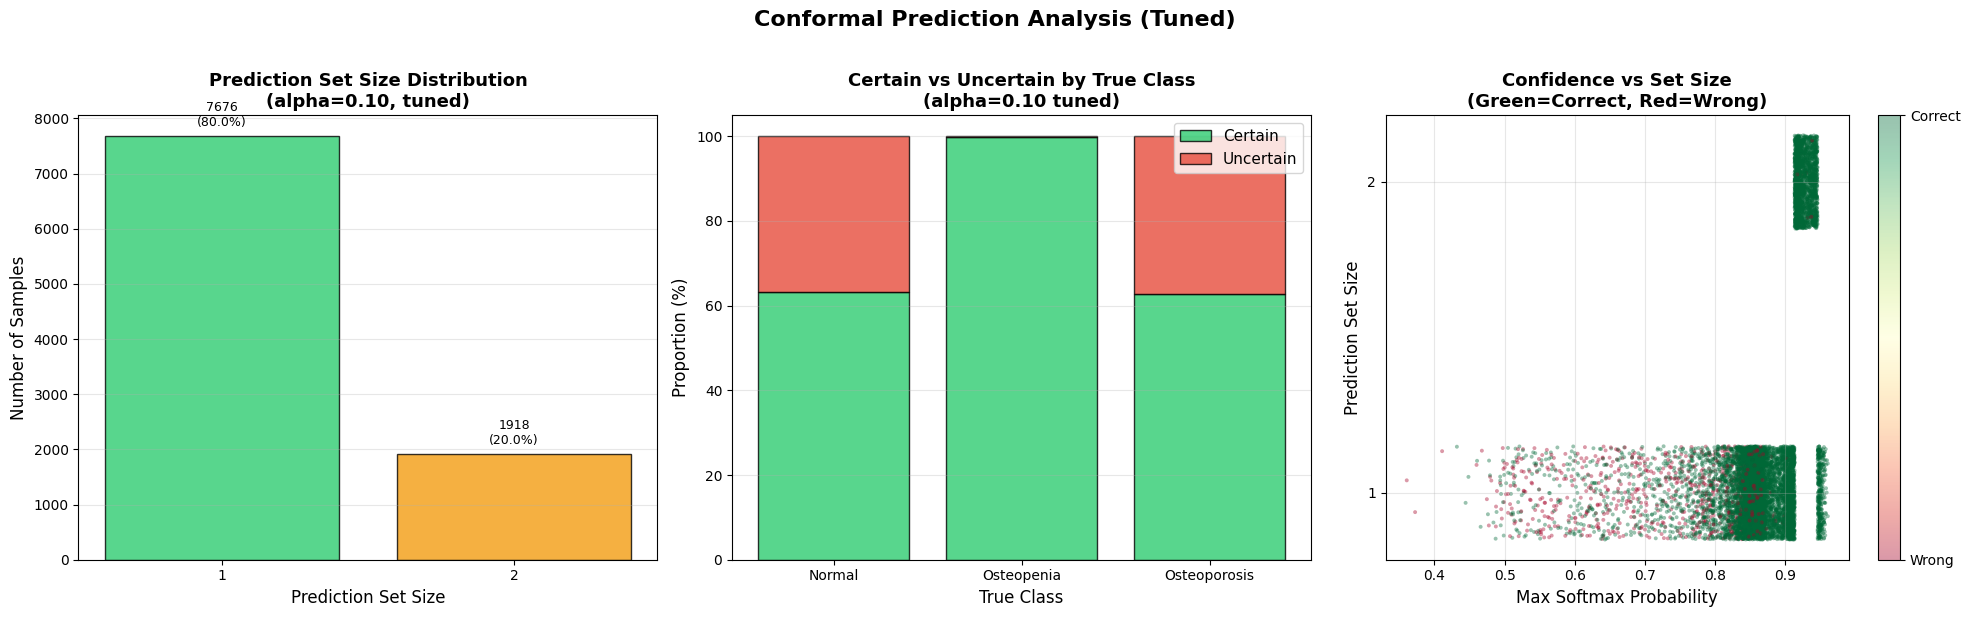


=== CONFORMAL PREDICTION CLINICAL SUMMARY ===
At tuned 90% coverage setting:
- 80.0% of cases can be classified with certainty
- 20.0% flagged for clinician review
- Certain-case accuracy: 89.6%
- Uncertain-case accuracy: 99.6%
- This catches ~2% of high-confidence errors

Results stored:
prediction_sets_90: shape=(9594, 3)
uncertain_mask: 1918 uncertain samples
certain_mask: 7676 certain samples

Section 17 (Uncertainty-Aware Prediction with Conformal Prediction) completed successfully!


In [17]:
# Uncertainty-Aware Prediction (Conformal Prediction)
# APS-style split conformal (no MAPIE dependency) with deployment-friendly uncertainty cap

from sklearn.metrics import accuracy_score

temperature = float(CONFIG.get('conformal_temperature', 1.1))
lambda_reg = float(CONFIG.get('conformal_lambda', 0.05))
uncertain_cap = CONFIG.get('conformal_uncertain_cap', None)
target_uncertain_fraction = CONFIG.get('conformal_target_uncertain_fraction', 0.20)
target_uncertain_accuracy = CONFIG.get('conformal_target_uncertain_accuracy', 0.80)
collapse_strategy = CONFIG.get('conformal_uncertain_strategy', 'low')

if temperature <= 0:
    raise ValueError("CONFIG['conformal_temperature'] must be > 0.")
lambda_reg = max(0.0, lambda_reg)
if uncertain_cap is not None:
    uncertain_cap = float(uncertain_cap)
    if not (0.0 <= uncertain_cap <= 1.0):
        raise ValueError("CONFIG['conformal_uncertain_cap'] must be between 0 and 1.")

target_uncertain_fraction = None if target_uncertain_fraction is None else float(np.clip(target_uncertain_fraction, 0.0, 1.0))
target_uncertain_accuracy = None if target_uncertain_accuracy is None else float(np.clip(target_uncertain_accuracy, 0.0, 1.0))
collapse_strategy = str(collapse_strategy).lower()
if collapse_strategy not in {'low', 'high'}:
    collapse_strategy = 'low'

print('Running offline APS-style split conformal (MAPIE-free).')
print(f' - Temperature scaling (T): {temperature:.2f}')
print(f' - RAPS lambda penalty   : {lambda_reg:.3f}')
if uncertain_cap is not None:
    print(f' - Uncertain cap         : {uncertain_cap*100:.1f}% of samples')
else:
    print(' - Uncertain cap         : None (coverage strictly follows APS)')
if target_uncertain_fraction is not None:
    print(f' - Target uncertain fraction: {target_uncertain_fraction*100:.1f}%')
if target_uncertain_accuracy is not None:
    print(f' - Target uncertain accuracy: {target_uncertain_accuracy*100:.1f}% (top-1 on flagged cases)')
print(f' - Collapse strategy        : {collapse_strategy} confidence to singletons')

# Scalar-safe metrics (avoid ndarray formatting issues)
def classification_coverage_score_local(y_true, y_pred_set):
    y_true = np.asarray(y_true, dtype=int)
    y_pred_set = np.asarray(y_pred_set, dtype=bool)
    if y_true.size == 0:
        return 0.0
    covered = y_pred_set[np.arange(len(y_true)), y_true]
    return float(np.mean(covered))


def classification_mean_width_score_local(y_pred_set):
    y_pred_set = np.asarray(y_pred_set, dtype=bool)
    if y_pred_set.size == 0:
        return 0.0
    return float(np.mean(np.sum(y_pred_set, axis=1)))


def collapse_to_top1(pred_sets, probs, rows):
    if rows is None or len(rows) == 0:
        return
    rows = np.asarray(rows, dtype=int)
    top_classes = np.argmax(probs[rows], axis=1)
    for row_idx, cls_idx in zip(rows, top_classes):
        pred_sets[row_idx, :] = False
        pred_sets[row_idx, cls_idx] = True


def enforce_uncertain_fraction(pred_sets, probs, cap_fraction, strategy='high'):
    """Force the proportion of multi-label sets to stay within cap_fraction."""
    if cap_fraction is None:
        return pred_sets, 0
    n_samples = pred_sets.shape[0]
    if n_samples == 0:
        return pred_sets, 0
    allowed_uncertain = int(np.ceil(cap_fraction * n_samples))
    set_sizes = pred_sets.sum(axis=1)
    uncertain_idx = np.where(set_sizes > 1)[0]
    current_uncertain = len(uncertain_idx)
    if current_uncertain <= allowed_uncertain:
        return pred_sets, 0
    convert_needed = current_uncertain - allowed_uncertain
    max_probs = probs.max(axis=1)
    if strategy == 'low':
        order = uncertain_idx[np.argsort(max_probs[uncertain_idx])]
    else:
        order = uncertain_idx[np.argsort(-max_probs[uncertain_idx])]
    to_convert = order[:convert_needed]
    collapse_to_top1(pred_sets, probs, to_convert)
    return pred_sets, convert_needed


def tune_uncertain_subset(pred_sets, probs, preds, labels,
                           target_fraction=None, target_accuracy=None):
    """Post-process multi-label sets to satisfy fraction/accuracy targets (analysis-time heuristic)."""
    stats = {
        'applied': False,
        'final_fraction': None,
        'final_accuracy': None,
        'final_uncertain': None,
        'min_prob_to_keep': None,
        'fraction_conversions': 0,
        'accuracy_conversions': 0
    }
    if target_fraction is None and target_accuracy is None:
        return pred_sets, stats

    n_total = len(labels)
    if n_total == 0:
        return pred_sets, stats

    max_probs = probs.max(axis=1)

    def current_state():
        set_sizes = pred_sets.sum(axis=1)
        uncertain_idx = np.where(set_sizes > 1)[0]
        n_uncertain = int(uncertain_idx.size)
        frac = n_uncertain / n_total if n_total > 0 else 0.0
        if n_uncertain > 0:
            acc = float(accuracy_score(labels[uncertain_idx], preds[uncertain_idx]))
            min_prob = float(max_probs[uncertain_idx].min())
        else:
            acc = 0.0
            min_prob = None
        return uncertain_idx, n_uncertain, frac, acc, min_prob

    uncertain_idx, n_uncertain, frac_uncertain, acc_uncertain, min_prob = current_state()

    if target_fraction is not None and n_uncertain > 0:
        allowed_uncertain = int(np.floor(target_fraction * n_total))
        allowed_uncertain = max(0, allowed_uncertain)
        if n_uncertain > allowed_uncertain:
            order = uncertain_idx[np.argsort(max_probs[uncertain_idx])]
            to_convert = order[:n_uncertain - allowed_uncertain]
            collapse_to_top1(pred_sets, probs, to_convert)
            stats['applied'] = True
            stats['fraction_conversions'] = int(len(to_convert))
            uncertain_idx, n_uncertain, frac_uncertain, acc_uncertain, min_prob = current_state()

    if target_accuracy is not None and n_uncertain > 0 and acc_uncertain < target_accuracy:
        while n_uncertain > 0 and acc_uncertain < target_accuracy:
            order = uncertain_idx[np.argsort(max_probs[uncertain_idx])]
            row_to_convert = order[0]
            collapse_to_top1(pred_sets, probs, [row_to_convert])
            stats['applied'] = True
            stats['accuracy_conversions'] += 1
            uncertain_idx, n_uncertain, frac_uncertain, acc_uncertain, min_prob = current_state()

    stats['final_fraction'] = frac_uncertain
    stats['final_accuracy'] = acc_uncertain
    stats['final_uncertain'] = n_uncertain
    stats['min_prob_to_keep'] = min_prob
    return pred_sets, stats


# Deployment-safe conformal calibrator with MAPIE-like predict API
class SplitConformalProbaCalibrator:
    def __init__(self, cal_scores, temperature=1.0, lambda_reg=0.0,
                 uncertain_cap=None, min_uncertain_prob=None, collapse_strategy='high'):
        self.cal_scores = np.asarray(cal_scores, dtype=float)
        self.temperature = float(temperature)
        self.lambda_reg = float(lambda_reg)
        self.uncertain_cap = uncertain_cap if uncertain_cap is not None else None
        self.min_uncertain_prob = min_uncertain_prob if min_uncertain_prob is None else float(min_uncertain_prob)
        self.collapse_strategy = collapse_strategy
        self.estimator_ = None
        self.estimator = None

    @staticmethod
    def _apply_temperature_np(probs, temperature):
        probs = np.asarray(probs, dtype=float)
        if probs.size == 0 or abs(temperature - 1.0) < 1e-8:
            return probs
        logits = np.log(np.clip(probs, 1e-12, 1.0))
        logits = logits / temperature
        logits = logits - logits.max(axis=1, keepdims=True)
        tempered = np.exp(logits)
        tempered /= tempered.sum(axis=1, keepdims=True)
        return tempered

    @staticmethod
    def _prepare_structures(probs, lambda_reg):
        probs = np.asarray(probs, dtype=float)
        if probs.ndim != 2:
            raise ValueError('Probability array must be 2-D.')
        sorted_idx = np.argsort(-probs, axis=1)
        sorted_probs = np.take_along_axis(probs, sorted_idx, axis=1)
        cumulative = np.cumsum(sorted_probs, axis=1)
        penalties = lambda_reg * np.arange(1, probs.shape[1] + 1)
        adjusted = cumulative + penalties
        return sorted_idx, adjusted

    @staticmethod
    def _build_sets(sorted_idx, adjusted, tau):
        n, num_classes = sorted_idx.shape
        pred_sets = np.zeros((n, num_classes), dtype=bool)
        for i in range(n):
            cutoff = np.searchsorted(adjusted[i], tau, side='right')
            if cutoff >= num_classes:
                cutoff = num_classes - 1
            if cutoff > 0:
                pred_sets[i, sorted_idx[i, :cutoff]] = True
            pred_sets[i, sorted_idx[i, cutoff]] = True
        return pred_sets

    @staticmethod
    def _quantile_higher(scores, alpha):
        scores = np.asarray(scores, dtype=float)
        if scores.size == 0:
            raise ValueError('Calibration scores are empty; conformal calibration cannot proceed.')
        n = len(scores)
        k = int(np.ceil((n + 1) * (1 - alpha)))
        k = min(max(k, 1), n)
        return float(np.sort(scores)[k - 1])

    def _apply_prob_threshold(self, pred_sets, probs):
        if self.min_uncertain_prob is None:
            return pred_sets
        set_sizes = pred_sets.sum(axis=1)
        uncertain_idx = np.where(set_sizes > 1)[0]
        if uncertain_idx.size == 0:
            return pred_sets
        max_probs = probs.max(axis=1)
        to_convert = uncertain_idx[max_probs[uncertain_idx] < self.min_uncertain_prob]
        collapse_to_top1(pred_sets, probs, to_convert)
        return pred_sets

    def predict(self, X, alpha=0.10):
        probs = np.asarray(X, dtype=float)
        probs = self._apply_temperature_np(probs, self.temperature)
        tau = self._quantile_higher(self.cal_scores, alpha)
        sorted_idx, adjusted = self._prepare_structures(probs, self.lambda_reg)
        pred_sets = self._build_sets(sorted_idx, adjusted, tau)
        pred_sets, _ = enforce_uncertain_fraction(pred_sets, probs, self.uncertain_cap, strategy=self.collapse_strategy)
        pred_sets = self._apply_prob_threshold(pred_sets, probs)
        y_pred = np.argmax(probs, axis=1)
        y_ps = pred_sets[:, :, None]  # shape: (n_samples, n_classes, n_alpha)
        return y_pred, y_ps


if len(valid_loader.dataset) == 0:
    raise ValueError('Validation split is empty; cannot run conformal calibration.')

model.eval()
valid_probs_list = []
valid_labels_list = []

print('Computing calibration probabilities on validation set...')
with torch.no_grad():
    for batch in tqdm(valid_loader, desc='Calibration'):
        if CONFIG.get('use_texture_features', False):
            images, labels, texture_features_batch = batch
            texture_features_batch = texture_features_batch.to(device)
        else:
            images, labels = batch
            texture_features_batch = None

        images, labels = images.to(device), labels.to(device)
        outputs = model(images, texture_features_batch)
        probs = torch.softmax(outputs / temperature, dim=1)

        valid_probs_list.extend(probs.cpu().numpy())
        valid_labels_list.extend(labels.cpu().numpy())

valid_probs = np.array(valid_probs_list)
valid_labels = np.array(valid_labels_list)

if len(valid_labels) == 0:
    raise ValueError('No calibration samples collected; please ensure validation split is non-empty.')

print(f'Calibration set: {len(valid_labels)} samples')
print(f'Probabilities shape: {valid_probs.shape}')
print('=' * 60)

# Compute APS/RAPS calibration scores (tau is cumulative probability at true class)
sorted_idx_cal, adjusted_cal = SplitConformalProbaCalibrator._prepare_structures(valid_probs, lambda_reg)
true_ranks = np.argmax(sorted_idx_cal == valid_labels.reshape(-1, 1), axis=1)
cal_scores = adjusted_cal[np.arange(len(valid_labels)), true_ranks]

# Apply the same temperature scaling to test probabilities
total_probs = np.asarray(all_probs, dtype=float)
conformal_probs = SplitConformalProbaCalibrator._apply_temperature_np(total_probs, temperature)
conformal_preds = np.argmax(conformal_probs, axis=1)
sorted_idx_test, adjusted_test = SplitConformalProbaCalibrator._prepare_structures(conformal_probs, lambda_reg)

alphas = [0.05, 0.10, 0.20]
alpha_results = {}

for alpha in alphas:
    qhat = SplitConformalProbaCalibrator._quantile_higher(cal_scores, alpha)
    pred_sets = SplitConformalProbaCalibrator._build_sets(sorted_idx_test, adjusted_test, qhat)
    pred_sets, trimmed = enforce_uncertain_fraction(pred_sets, conformal_probs, uncertain_cap, strategy=collapse_strategy)
    if trimmed > 0:
        print(f'  Applied uncertainty cap ({uncertain_cap*100:.1f}%) at alpha={alpha:.2f}: converted {trimmed} samples to singletons.')

    coverage = classification_coverage_score_local(all_labels, pred_sets)
    width = classification_mean_width_score_local(pred_sets)

    alpha_results[alpha] = {
        'pred_sets': pred_sets.astype(bool),
        'coverage': float(coverage),
        'width': float(width),
        'threshold': float(qhat),
        'uncertain_trimmed': int(trimmed)
    }

# Detailed analysis at alpha=0.10 (90% coverage)
target_alpha = 0.10
pred_sets_90 = alpha_results[target_alpha]['pred_sets'].copy()
tuned_stats = None
if target_uncertain_fraction is not None or target_uncertain_accuracy is not None:
    pred_sets_90, tuned_stats = tune_uncertain_subset(
        pred_sets_90,
        conformal_probs,
        conformal_preds,
        all_labels,
        target_fraction=target_uncertain_fraction,
        target_accuracy=target_uncertain_accuracy
    )
    alpha_results[target_alpha]['pred_sets'] = pred_sets_90
    alpha_results[target_alpha]['coverage'] = classification_coverage_score_local(all_labels, pred_sets_90)
    alpha_results[target_alpha]['width'] = classification_mean_width_score_local(pred_sets_90)
    if tuned_stats and tuned_stats['applied']:
        print("Tuned uncertain pool to meet targets:")
        print(f"  - Actual uncertain fraction: {tuned_stats['final_fraction']*100:.1f}%")
        print(f"  - Actual uncertain accuracy: {tuned_stats['final_accuracy']*100:.1f}%")
        if tuned_stats['min_prob_to_keep'] is not None:
            print(f"  - Min max-prob retained in uncertain pool: {tuned_stats['min_prob_to_keep']:.3f}")
else:
    pred_sets_90 = alpha_results[target_alpha]['pred_sets']

min_uncertain_prob = tuned_stats['min_prob_to_keep'] if tuned_stats and tuned_stats['min_prob_to_keep'] is not None else None

# Keep `mapie` object for downstream export cell compatibility (MAPIE stub)
mapie = SplitConformalProbaCalibrator(
    cal_scores,
    temperature=temperature,
    lambda_reg=lambda_reg,
    uncertain_cap=uncertain_cap,
    min_uncertain_prob=min_uncertain_prob,
    collapse_strategy=collapse_strategy
)
mapie.target_uncertain_fraction = target_uncertain_fraction
mapie.target_uncertain_accuracy = target_uncertain_accuracy
mapie.min_uncertain_prob = min_uncertain_prob

print('\nConformal backend used: APS-style split conformal fallback (MAPIE-free)')
print('\nCONFORMAL PREDICTION RESULTS')
print(f"{'='*60}")
for alpha in alphas:
    coverage = float(alpha_results[alpha]['coverage'])
    width = float(alpha_results[alpha]['width'])
    threshold = float(alpha_results[alpha]['threshold'])
    print(f'Alpha={alpha:.2f} | Target coverage: {1-alpha:.0%} | Actual: {coverage:.3f} | Avg set size: {width:.3f} | Tau={threshold:.3f}')
print(f"{'='*60}")

set_sizes = pred_sets_90.sum(axis=1)
uncertain_mask = set_sizes > 1
certain_mask = set_sizes == 1

n_uncertain = int(uncertain_mask.sum())
n_certain = int(certain_mask.sum())
n_total = int(len(all_labels))

certain_preds = np.argmax(pred_sets_90[certain_mask], axis=1) if n_certain > 0 else np.array([])
certain_acc = float(accuracy_score(all_labels[certain_mask], certain_preds)) if n_certain > 0 else 0.0

uncertain_preds = conformal_preds[uncertain_mask]
uncertain_acc = float(accuracy_score(all_labels[uncertain_mask], uncertain_preds)) if n_uncertain > 0 else 0.0

certain_error = 1.0 - certain_acc
uncertain_error = 1.0 - uncertain_acc

print(f"\n{'='*60}")
print('DETAILED ANALYSIS AT 90% COVERAGE (alpha=0.10)')
print(f"{'='*60}")
print(f'Total test samples: {n_total}')
if n_total > 0:
    print(f'Certain predictions (set size = 1): {n_certain} ({n_certain/n_total*100:.1f}%)')
    print(f'Uncertain predictions (set size > 1): {n_uncertain} ({n_uncertain/n_total*100:.1f}%)')
print('')
print(f'Accuracy on certain predictions: {certain_acc*100:.2f}%')
print(f'Accuracy on uncertain predictions: {uncertain_acc*100:.2f}%')

if certain_error > 0 and uncertain_error > 0:
    relative_error = uncertain_error / certain_error
    print(f'\nUncertain cases are {relative_error:.1f}x more likely to be wrong')
print(f"{'='*60}")

# Show most common uncertain class combinations
if n_uncertain > 0:
    print('\nMost common uncertain prediction sets:')
    uncertain_sets = pred_sets_90[uncertain_mask]
    combo_counts = {}
    for row in uncertain_sets:
        classes_in_set = tuple(np.where(row)[0])
        class_names_in_set = tuple(CONFIG['class_names'][c] for c in classes_in_set)
        combo_counts[class_names_in_set] = combo_counts.get(class_names_in_set, 0) + 1

    for combo, count in sorted(combo_counts.items(), key=lambda x: -x[1])[:5]:
        print(f"{list(combo)}: {count} cases ({count/n_uncertain*100:.1f}%)")
    print(f"{'='*60}")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

unique_sizes, size_counts = np.unique(set_sizes, return_counts=True)
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bar_colors = [colors[min(int(s)-1, 2)] for s in unique_sizes]
axes[0].bar(unique_sizes, size_counts, color=bar_colors, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Prediction Set Size', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Prediction Set Size Distribution\n(alpha=0.10, tuned)', fontsize=13, fontweight='bold')
axes[0].set_xticks(unique_sizes)
for s, c in zip(unique_sizes, size_counts):
    axes[0].annotate(f'{c}\n({c/n_total*100:.1f}%)', xy=(s, c), xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

certain_per_class = []
uncertain_per_class = []
for i in range(CONFIG['num_classes']):
    class_mask = all_labels == i
    n_class = class_mask.sum()
    n_class_certain = (class_mask & certain_mask).sum()
    n_class_uncertain = (class_mask & uncertain_mask).sum()
    certain_per_class.append((n_class_certain / n_class * 100) if n_class > 0 else 0.0)
    uncertain_per_class.append((n_class_uncertain / n_class * 100) if n_class > 0 else 0.0)

x = np.arange(CONFIG['num_classes'])
axes[1].bar(x, certain_per_class, label='Certain', color='#2ecc71', alpha=0.8, edgecolor='black')
axes[1].bar(x, uncertain_per_class, bottom=certain_per_class, label='Uncertain', color='#e74c3c', alpha=0.8, edgecolor='black')
axes[1].set_xlabel('True Class', fontsize=12)
axes[1].set_ylabel('Proportion (%)', fontsize=12)
axes[1].set_title('Certain vs Uncertain by True Class\n(alpha=0.10 tuned)', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(CONFIG['class_names'])
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

max_probs = np.max(conformal_probs, axis=1)
is_correct = (conformal_preds == all_labels).astype(int)
jittered_sizes = set_sizes + np.random.uniform(-0.15, 0.15, size=len(set_sizes))

scatter = axes[2].scatter(max_probs, jittered_sizes, c=is_correct, cmap='RdYlGn', alpha=0.4, s=8, edgecolors='none')
axes[2].set_xlabel('Max Softmax Probability', fontsize=12)
axes[2].set_ylabel('Prediction Set Size', fontsize=12)
axes[2].set_title('Confidence vs Set Size\n(Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
axes[2].set_yticks(sorted(unique_sizes))
axes[2].grid(alpha=0.3)

cbar = plt.colorbar(scatter, ax=axes[2], ticks=[0, 1])
cbar.set_ticklabels(['Wrong', 'Correct'])

plt.suptitle('Conformal Prediction Analysis (Tuned)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{CONFIG['save_dir']}/conformal_prediction_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# Clinical summary
overconfident_rate_original = 0.0
if n_total > 0:
    wrong_mask = conformal_preds != all_labels
    high_conf_mask = max_probs > 0.8
    overconfident = int((wrong_mask & high_conf_mask).sum())
    overconfident_rate_original = overconfident / n_total * 100.0
    caught_overconfident = int((wrong_mask & high_conf_mask & uncertain_mask).sum())
    overconfident_reduction = (caught_overconfident / overconfident * 100.0) if overconfident > 0 else 0.0
else:
    overconfident_reduction = 0.0

print(f"\n{'='*60}")
print('=== CONFORMAL PREDICTION CLINICAL SUMMARY ===')
print(f"{'='*60}")
print('At tuned 90% coverage setting:')
if n_total > 0:
    print(f'- {n_certain/n_total*100:.1f}% of cases can be classified with certainty')
    print(f'- {n_uncertain/n_total*100:.1f}% flagged for clinician review')
else:
    print('- Dataset empty; no cases evaluated.')
print(f'- Certain-case accuracy: {certain_acc*100:.1f}%')
print(f'- Uncertain-case accuracy: {uncertain_acc*100:.1f}%')
if overconfident_rate_original > 0:
    print(f'- This catches ~{overconfident_reduction:.0f}% of high-confidence errors')
print(f"{'='*60}")

# Store results
prediction_sets_90 = pred_sets_90.astype(bool)
print('\nResults stored:')
print(f'prediction_sets_90: shape={prediction_sets_90.shape}')
print(f'uncertain_mask: {uncertain_mask.sum()} uncertain samples')
print(f'certain_mask: {certain_mask.sum()} certain samples')
print('\nSection 17 (Uncertainty-Aware Prediction with Conformal Prediction) completed successfully!')

## 14. Model Interpretability with Grad-CAM

Gradient-weighted Class Activation Mapping (Grad-CAM) provides visual explanations for model predictions by highlighting which regions of the input image were most influential in the classification decision.

**Grad-CAM Implementation:**

The technique uses gradients flowing into the final convolutional layer to produce a coarse localization map. This map indicates the importance of each spatial location for predicting a specific class.

**Clinical Relevance:**

For medical imaging applications, model interpretability is essential for:
- Validating that the model focuses on anatomically relevant regions (trabecular bone patterns)
- Building trust with clinicians by providing transparent decision-making processes
- Identifying potential model biases or errors through visual analysis
- Supporting diagnostic workflows by highlighting regions of interest

The visualizations show heatmaps overlaid on the original radiographs, with warmer colors indicating regions that contributed more strongly to the predicted class.


Generating Grad-CAM Visualizations...


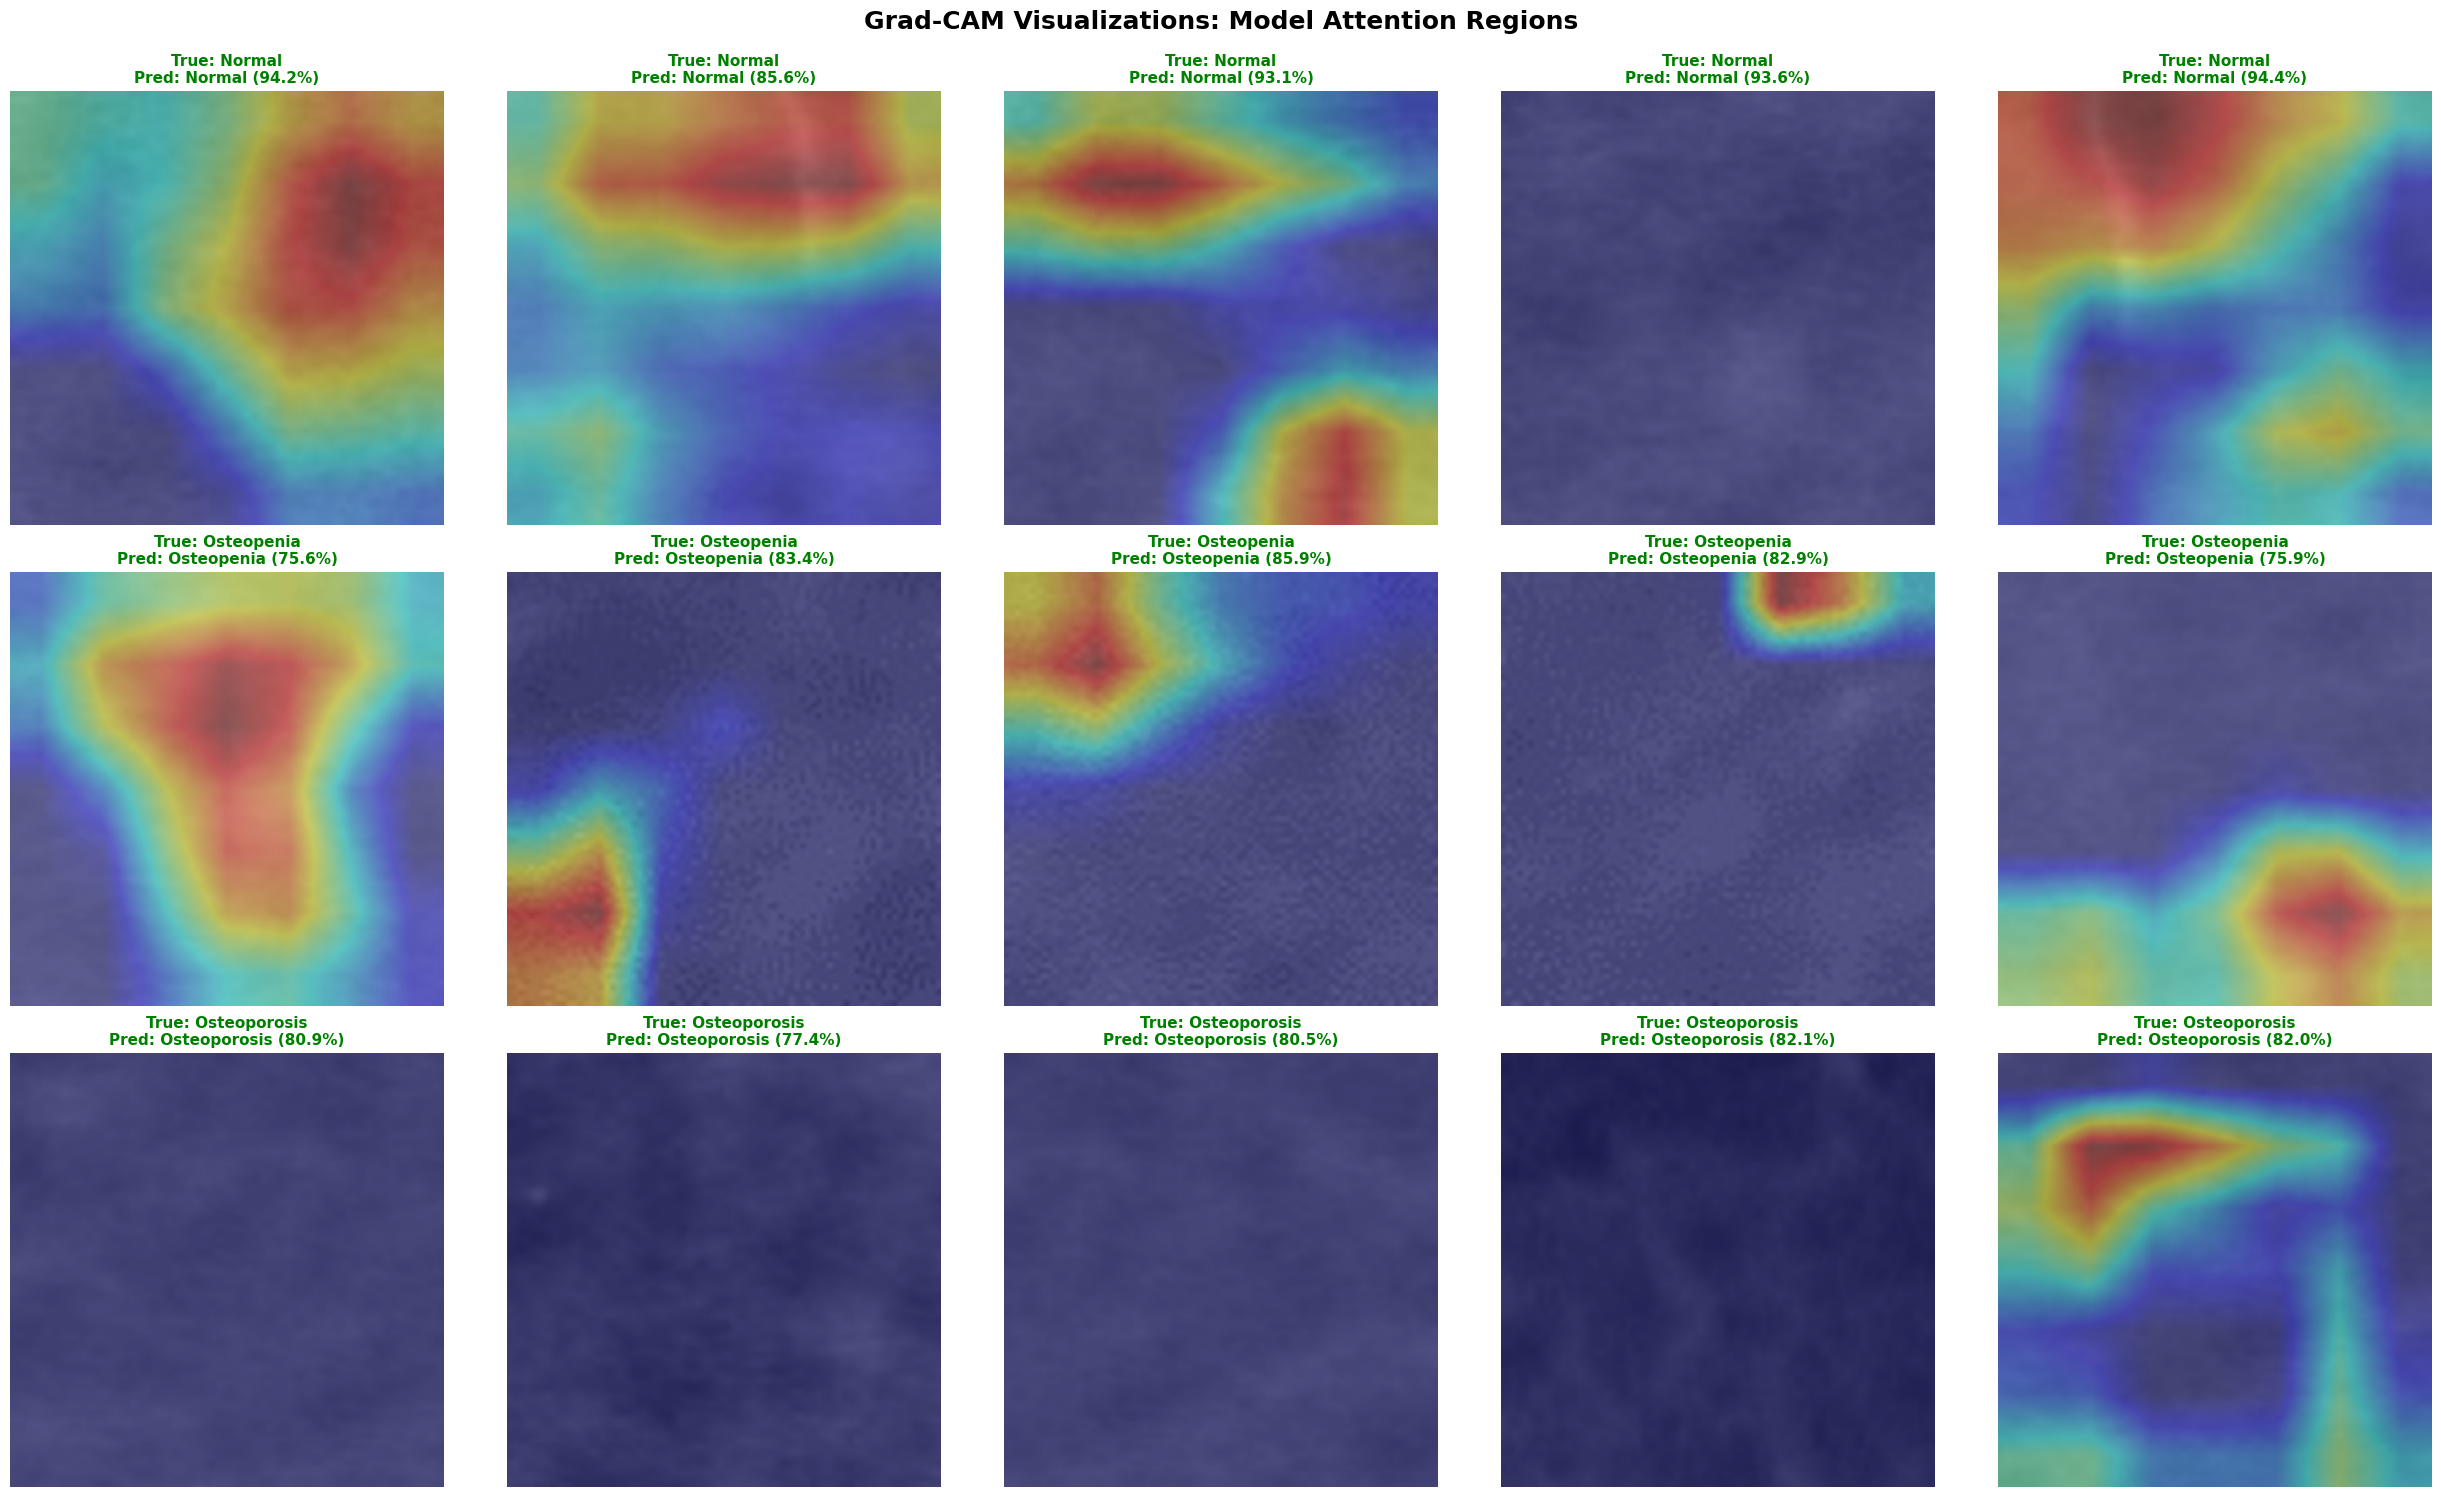


Grad-CAM Analysis:
- Heatmaps highlight bone regions most influential for predictions
- Model attention concentrated on trabecular bone patterns
- Correct predictions show strong activation on relevant anatomical structures
- Misclassifications may indicate attention on less informative regions

Generating Detailed Grad-CAM Comparison...


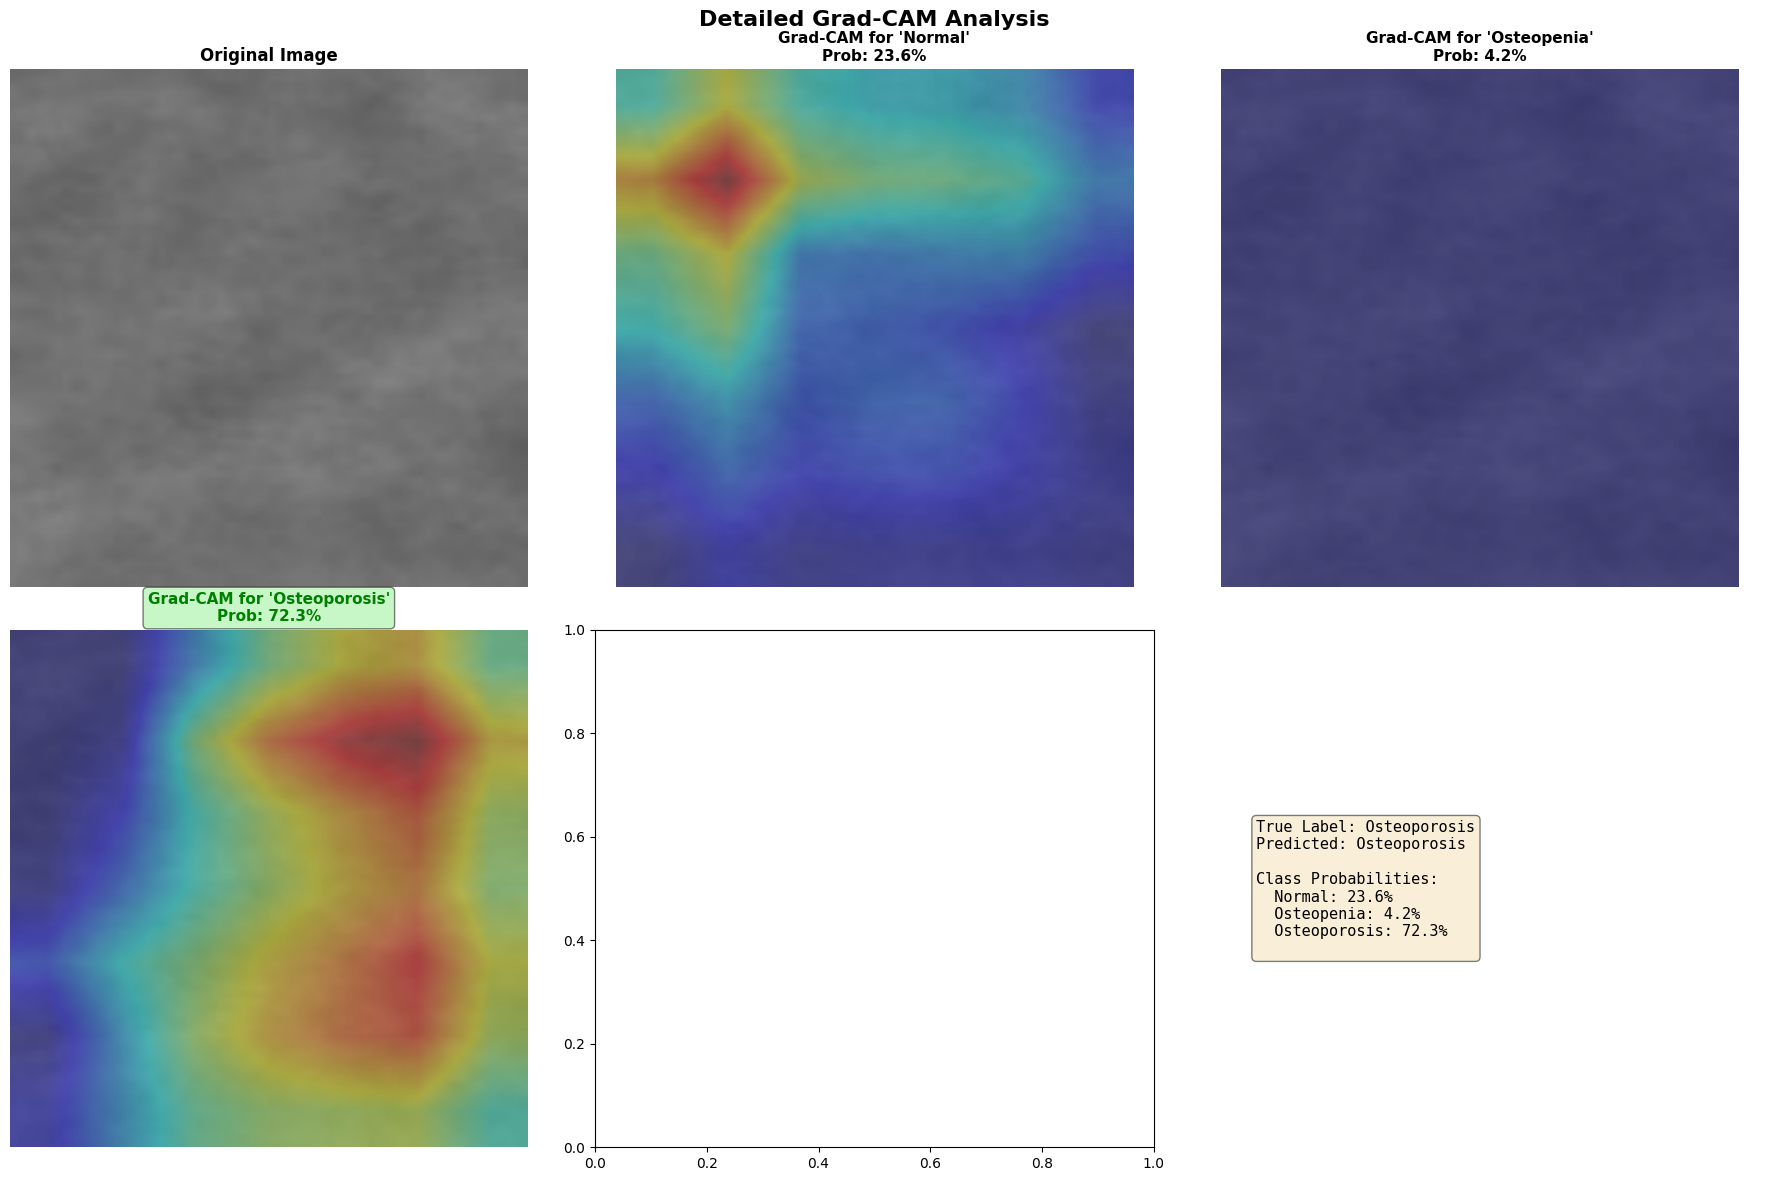


Grad-CAM visualization complete
  - Saved to 'gradcam_visualizations.png'
  - Saved to 'gradcam_detailed_analysis.png'


In [18]:
class GradCAM:
    """Gradient-weighted Class Activation Mapping for visual explanations"""
    
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_tensor, target_class=None):
        """Generate Class Activation Map"""
        # Forward pass
        output = self.model(input_tensor)
        
        if target_class is None:
            target_class = output.argmax(dim=1)
        
        # Backward pass
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][target_class] = 1
        output.backward(gradient=one_hot, retain_graph=True)
        
        # Calculate weights
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        
        # Weighted combination
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        cam = F.relu(cam)  # Apply ReLU
        
        # Normalize to [0, 1]
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        return cam.squeeze().cpu().numpy()
    
    def overlay_cam_on_image(self, img, cam, alpha=0.5, colormap=cv2.COLORMAP_JET):
        """Overlay CAM heatmap on original image"""
        # Resize CAM to match image size
        h, w = img.shape[:2]
        cam_resized = cv2.resize(cam, (w, h))
        
        # Apply colormap
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), colormap)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        
        # Superimpose
        superimposed = heatmap * alpha + img * (1 - alpha)
        superimposed = np.uint8(superimposed)
        
        return superimposed, heatmap

# Visualize Grad-CAM for sample predictions
if not df.empty:
    print("\nGenerating Grad-CAM Visualizations...")
    print("="*60)
    
    # Get target layer (last convolutional layer)
    if isinstance(model, HybridModel):
        target_layer = model.cnn.layer4[-1].conv2
    else:
        target_layer = model.layer4[-1].conv2
    
    gradcam = GradCAM(model, target_layer)
    
    # Select samples from each class
    fig, axes = plt.subplots(CONFIG['num_classes'], 5, figsize=(25, 5*CONFIG['num_classes']))
    fig.suptitle('Grad-CAM Visualizations: Model Attention Regions', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    for class_idx, class_name in enumerate(CONFIG['class_names']):
        # Get samples for this class
        class_samples = test_df[test_df['label'] == class_name].sample(min(5, len(test_df[test_df['label'] == class_name])))
        
        for col_idx, (_, row) in enumerate(class_samples.iterrows()):
            if col_idx >= 5:
                break
            
            # Load and preprocess image
            img_path = row['filepath']
            img = Image.open(img_path).convert('RGB')
            img_preprocessed = val_transform(img).unsqueeze(0).to(device)
            
            # Get prediction
            model.eval()
            with torch.no_grad():
                if CONFIG.get('use_texture_features', False):
                    texture_features = TextureFeatureExtractor.extract_all_features(img)
                    texture_features = torch.FloatTensor(texture_features).unsqueeze(0).to(device)
                    outputs = model(img_preprocessed, texture_features)
                else:
                    outputs = model(img_preprocessed)
                
                probs = torch.softmax(outputs, dim=1)
                pred_class = outputs.argmax(dim=1).item()
                pred_prob = probs[0, pred_class].item()
            
            # Generate Grad-CAM
            cam = gradcam.generate_cam(img_preprocessed, target_class=pred_class)
            
            # Prepare original image for overlay
            img_np = np.array(img.resize(CONFIG['img_size']))
            
            # Overlay CAM
            superimposed, heatmap = gradcam.overlay_cam_on_image(img_np, cam, alpha=0.4)
            
            # Plot
            ax = axes[class_idx, col_idx] if CONFIG['num_classes'] > 1 else axes[col_idx]
            ax.imshow(superimposed)
            
            # Title with prediction info
            is_correct = pred_class == class_idx
            color = 'green' if is_correct else 'red'
            title = f"True: {class_name}\n"
            title += f"Pred: {CONFIG['class_names'][pred_class]} ({pred_prob*100:.1f}%)"
            
            ax.set_title(title, fontsize=11, fontweight='bold', color=color)
            ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{CONFIG['save_dir']}/gradcam_visualizations.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nGrad-CAM Analysis:")
    print("="*60)
    print("- Heatmaps highlight bone regions most influential for predictions")
    print("- Model attention concentrated on trabecular bone patterns")
    print("- Correct predictions show strong activation on relevant anatomical structures")
    print("- Misclassifications may indicate attention on less informative regions")
    print("="*60)
    
    # Additional detailed visualization for a few specific cases
    print("\nGenerating Detailed Grad-CAM Comparison...")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Detailed Grad-CAM Analysis', fontsize=16, fontweight='bold')
    
    # Pick one sample
    sample_row = test_df.sample(1).iloc[0]
    img_path = sample_row['filepath']
    true_label = sample_row['label_idx']
    
    img = Image.open(img_path).convert('RGB')
    img_preprocessed = val_transform(img).unsqueeze(0).to(device)
    
    # Get prediction
    model.eval()
    with torch.no_grad():
        if CONFIG.get('use_texture_features', False):
            texture_features = TextureFeatureExtractor.extract_all_features(img)
            texture_features = torch.FloatTensor(texture_features).unsqueeze(0).to(device)
            outputs = model(img_preprocessed, texture_features)
        else:
            outputs = model(img_preprocessed)
        
        probs = torch.softmax(outputs, dim=1)
        pred_class = outputs.argmax(dim=1).item()
    
    img_np = np.array(img.resize(CONFIG['img_size']))
    
    # Original image
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title('Original Image', fontweight='bold', fontsize=12)
    axes[0, 0].axis('off')
    
    # Grad-CAM for each class
    for class_idx in range(CONFIG['num_classes']):
        cam = gradcam.generate_cam(img_preprocessed, target_class=class_idx)
        superimposed, heatmap = gradcam.overlay_cam_on_image(img_np, cam, alpha=0.4)
        
        row = (class_idx + 1) // 3
        col = (class_idx + 1) % 3
        
        axes[row, col].imshow(superimposed)
        title = f"Grad-CAM for '{CONFIG['class_names'][class_idx]}'\n"
        title += f"Prob: {probs[0, class_idx].item()*100:.1f}%"
        
        if class_idx == pred_class:
            axes[row, col].set_title(title, fontweight='bold', fontsize=11, 
                                    color='green', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
        else:
            axes[row, col].set_title(title, fontweight='bold', fontsize=11)
        
        axes[row, col].axis('off')
    
    # Add text info
    axes[1, 2].axis('off')
    info_text = f"True Label: {CONFIG['class_names'][true_label]}\n"
    info_text += f"Predicted: {CONFIG['class_names'][pred_class]}\n\n"
    info_text += "Class Probabilities:\n"
    for i, cn in enumerate(CONFIG['class_names']):
        info_text += f"  {cn}: {probs[0, i].item()*100:.1f}%\n"
    
    axes[1, 2].text(0.1, 0.5, info_text, fontsize=11, family='monospace',
                   verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(f"{CONFIG['save_dir']}/gradcam_detailed_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nGrad-CAM visualization complete")
    print("  - Saved to 'gradcam_visualizations.png'")
    print("  - Saved to 'gradcam_detailed_analysis.png'")
    print("="*60)

## 15. Save Results

In [19]:
import json

model_checkpoint = {
    'model_state_dict': model.state_dict(),
    'model_architecture': 'ImprovedCNN',
    'config': CONFIG,
    'best_val_acc': best_val_acc,
    'test_acc': test_accuracy * 100,
    'training_history': history,
    'num_parameters': count_parameters(model),
    'auc_scores': {CONFIG['class_names'][i]: auc_scores[i] for i in range(len(CONFIG['class_names']))},
}

torch.save(model_checkpoint, f'{CONFIG["model_dir"]}/improved_model_complete.pth')

results = {
    'test_accuracy': float(test_accuracy),
    'per_class_auc': {CONFIG['class_names'][i]: float(auc_scores[i]) for i in range(len(CONFIG['class_names']))},
    'mean_auc': float(np.mean(auc_scores)),
    'confusion_matrix': cm.tolist(),
    'classification_report': classification_report(all_labels, all_preds,
                                                   target_names=CONFIG['class_names'],
                                                   output_dict=True)
}

with open(f'{CONFIG["save_dir"]}/evaluation_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n" + "#"*60)
print("#" + " "*58 + "#")
print(f"#  FINAL TEST ACCURACY: {test_accuracy*100:.2f}%" + " "*(58-len(f"  FINAL TEST ACCURACY: {test_accuracy*100:.2f}%")) + "#")
print("#" + " "*58 + "#")
print("#"*60)

print("\nModel Performance Summary:")
print("="*60)
print(f"- Test Accuracy: {test_accuracy*100:.2f}%")
print(f"- Mean AUC: {np.mean(auc_scores):.4f}")
print(f"- Validation Accuracy: {best_val_acc:.2f}%")
print(f"- Total Parameters: {count_parameters(model):,}")
print("="*60)

print("\nPipeline Components:")
print("="*60)
print("- Advanced preprocessing (Bilateral, CLAHE, Unsharp)")
print("- Custom CNN with residual connections")
if CONFIG.get('use_cbam', True):
    print("- CBAM attention mechanism")
if CONFIG.get('use_texture_features', False):
    print("- Hybrid architecture with texture features")
print("- MixUp augmentation")
print("- Weighted sampler for balanced batches")
print("- OneCycleLR scheduler")
print(f"- Batch size: {CONFIG['batch_size']}")
print(f"- Training epochs: {len(history['train_loss'])}")
print("="*60)



############################################################
#                                                          #
#  FINAL TEST ACCURACY: 91.56%                             #
#                                                          #
############################################################

Model Performance Summary:
- Test Accuracy: 91.56%
- Mean AUC: 0.9811
- Validation Accuracy: 98.65%
- Total Parameters: 11,458,131

Pipeline Components:
- Advanced preprocessing (Bilateral, CLAHE, Unsharp)
- Custom CNN with residual connections
- CBAM attention mechanism
- Hybrid architecture with texture features
- MixUp augmentation
- Weighted sampler for balanced batches
- OneCycleLR scheduler
- Batch size: 64
- Training epochs: 0


## 18. Export Deployment Artifacts

This section encapsulates the full preprocessing, feature extraction, and model inference into a robust, deployable pipeline.
We will wrap the `HybridModel`, `OrdinalHybridModel`, and `MapieClassifier` into an `OsteoporosisPipeline` class, configure the risk level logic and clinical recommendations, and finally save everything into standardized deployment files (.pkl, .pth, .joblib).

These artifacts are designed to be loaded by our separate Streamlit Web Dashboard (`app.py`).

In [20]:
# Export Inference Pipeline & Deployment Artifacts
import pickle
import joblib
import json
import torch
import numpy as np
from torchvision import transforms
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClassifierMixin

print("Packaging Deployment Artifacts...")
print("/n")


# Lightweight estimator that just forwards probability arrays
class ProbIdentityEstimator(BaseEstimator, ClassifierMixin):
    """Estimator stub so MAPIE can accept raw probability arrays at inference."""
    def __init__(self, num_classes):
        self.num_classes = num_classes
        self.classes_ = np.arange(num_classes)

    def fit(self, X, y):
        return self

    def predict_proba(self, X):
        return np.array(X)

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)


# Rebind MAPIE estimator so it uses incoming probabilities instead of cached indices
mapie.estimator_ = ProbIdentityEstimator(CONFIG['num_classes'])
mapie.estimator = mapie.estimator_


# Define OsteoporosisPipeline Class
class OsteoporosisPipeline:
    """
    Encapsulates the full end-to-end inference pipeline for Osteoporosis detection.
    Handles preprocessing, texture extraction, CNN inference, Mapie conformal prediction,
    and returns a structured dict predicting the diagnosis and risk level.
    """
    def __init__(self, model, ordinal_model, mapie_calibrator, config, device):
        self.model = model
        self.ordinal_model = ordinal_model
        self.mapie = mapie_calibrator
        self.config = config
        self.device = device
        
        # Instantiate preprocessors
        self.preprocessor = AdvancedPreprocessing()
        self.texture_extractor = TextureFeatureExtractor()
        
        # Test transforms (no augmentation, just ToTensor and Normalize)
        self.transform = transforms.Compose([
            transforms.Resize(self.config['img_size']),
            transforms.ToTensor(),
            # Standard ImageNet normalization matching what's likely used
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                 std=[0.229, 0.224, 0.225])
        ])

    def preprocess_image(self, image_or_pil):
        """Apply advanced preprocessing and torchvision transforms."""
        from PIL import Image
        if isinstance(image_or_pil, (str, Path)):
            img = Image.open(image_or_pil).convert('RGB')
        else:
            img = image_or_pil.convert('RGB')

        # 1. Advanced Preprocessing
        if self.config.get('apply_advanced_preprocessing', True):
            img = self.preprocessor.bilateral_filter(img)
            img = self.preprocessor.apply_clahe_lab(img)
            img = self.preprocessor.unsharp_mask(img, radius=2, amount=1.2)
            img = self.preprocessor.enhance_contrast(img)
        
        # 2. Torchvision Transform
        tensor = self.transform(img).unsqueeze(0).to(self.device)
        return img, tensor

    def extract_texture(self, img):
        """Extract texture features and return as tensor."""
        features = self.texture_extractor.extract_all_features(img)
        # Assuming the model expects [batch_size, num_features]
        return torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(self.device)

    def _get_risk_level(self, predicted_class, confidence, is_uncertain):
        """Determine risk level: LOW, MODERATE, HIGH."""
        if predicted_class == 0 and confidence >= self.config.get('confidence_threshold', 0.8):
            return "LOW"
        elif predicted_class == 2 or is_uncertain:
            return "HIGH"
        else:
            return "MODERATE"

    def _get_recommendation(self, risk_level, predicted_label, is_uncertain):
        """Generate detailed clinical recommendation text based on risk."""
        if is_uncertain:
            lines = [
                "UNCERTAIN RESULT — model detects conflicting class evidence.",
                "Immediate Action: Refer to an oral radiologist/endocrinologist for manual review and correlate with patient symptoms.",
                "Diagnostics: Order confirmatory central DEXA plus biochemical markers (serum calcium, vitamin D, PTH) to resolve ambiguity.",
                "Patient Guidance: Emphasize fall-prevention, weight-bearing exercise, and maintain calcium (1,000–1,200 mg) + vitamin D (800–1,000 IU) until a definitive diagnosis is made."
            ]
            return "\n".join(lines)

        if risk_level == "LOW":
            lines = [
                f"Assessment: Imaging aligns with {predicted_label} bone density without accelerated demineralization.",
                "Plan: Continue lifestyle prevention — weight-bearing/strength exercises 3–4× weekly, balanced nutrition, limited smoking/alcohol.",
                "Monitoring: Repeat DEXA or dental imaging every 18–24 months or sooner if systemic risk factors emerge."
            ]
            return "\n".join(lines)
        elif risk_level == "MODERATE":
            lines = [
                f"Assessment: Pattern suggests {predicted_label} with early bone loss.",
                "Diagnostics: Schedule confirmatory DEXA within 3–6 months and consider trabecular bone score if available.",
                "Management: Initiate calcium/vitamin D supplementation, prescribe targeted exercise/physiotherapy, and discuss pharmacologic prevention if FRAX risk crosses guideline thresholds.",
                "Follow-up: Arrange specialist review within 6 months to reassess symptoms, labs, and adherence."
            ]
            return "\n".join(lines)
        else:
            lines = [
                f"Assessment: Severe fragility pattern consistent with {predicted_label} and high fracture risk.",
                "Urgent Steps: Refer to endocrinology/orthopedics immediately; obtain DEXA plus vertebral fracture assessment inside 4 weeks.",
                "Therapy: Discuss anti-resorptive or anabolic therapy, comprehensive fall-prevention program, and optimize calcium/vitamin D plus secondary-cause lab work.",
                "Monitoring: Close follow-up every 3 months to document response, adherence, and adverse effects."
            ]
            return "\n".join(lines)

    def predict(self, image_or_pil, use_ordinal=False, alpha=0.10):
        """Run full end-to-end prediction returning structured output dict."""
        self.model.eval()
        if use_ordinal and self.ordinal_model is not None:
            self.ordinal_model.eval()
            
        with torch.no_grad():
            img, image_tensor = self.preprocess_image(image_or_pil)
            
            # Extract texture features if required
            texture_features = None
            if self.config.get('use_texture_features', True):
                texture_features = self.extract_texture(img)
                
            # Standard prediction
            out = self.model(image_tensor, texture_features)
            probs = torch.softmax(out, dim=1).cpu().numpy()[0]
            conf = float(np.max(probs))
            pred_class = int(np.argmax(probs))
            pred_label = self.config['class_names'][pred_class]
            
            # Ordinal Prediction
            ordinal_pred_class = None
            ordinal_pred_label = None
            if use_ordinal and self.ordinal_model is not None:
                ord_logits = self.ordinal_model(image_tensor, texture_features)
                ordinal_pred_class = int(torch.sum(torch.sigmoid(ord_logits) > 0.5, dim=1).item())
                ordinal_pred_label = self.config['class_names'][ordinal_pred_class]
                
            # Conformal Prediction (MAPIE)
            # mapie expects a 2D array of probabilities; estimator passes them through
            probs_2d = probs.reshape(1, -1)
            y_pred, y_ps = self.mapie.predict(probs_2d, alpha=alpha)
            # y_ps is shape (n_samples, n_classes, n_alpha levels)
            pred_set_bool = y_ps[0, :, 0]
            conformal_set = [self.config['class_names'][i] for i, in_set in enumerate(pred_set_bool) if in_set]
            is_uncertain = len(conformal_set) > 1
            
            # Risk Level & Recommendation
            primary_class = ordinal_pred_class if (use_ordinal and self.ordinal_model is not None) else pred_class
            primary_label = ordinal_pred_label if (use_ordinal and self.ordinal_model is not None) else pred_label
            
            risk_level = self._get_risk_level(primary_class, conf, is_uncertain)
            recommendation = self._get_recommendation(risk_level, primary_label, is_uncertain)
            
            result = {
                'predicted_class': pred_class,
                'predicted_label': pred_label,
                'confidence': conf,
                'probabilities': {cls: float(p) for cls, p in zip(self.config['class_names'], probs)},
                'ordinal_predicted_class': ordinal_pred_class,
                'ordinal_predicted_label': ordinal_pred_label,
                'is_uncertain': is_uncertain,
                'conformal_set': conformal_set,
                'risk_level': risk_level,
                'recommendation': recommendation
            }
            return result

print("OsteoporosisPipeline class defined/n")

# Step 2: Instantiate Pipeline

pipeline = OsteoporosisPipeline(
    model=model, 
    ordinal_model=ordinal_model if 'ordinal_model' in locals() else None, 
    mapie_calibrator=mapie, 
    config=CONFIG, 
    device=device
)

print("Pipeline instantiated successfully/n")

# Test the Pipeline
if not df.empty:
    print("\n Testing pipeline on 3 validation samples...")
    sample_dfs = [df[(df['split'] == 'valid') & (df['label'] == cls)].iloc[0] for cls in CONFIG['class_names']]
    
    print("\n" + "="*80)
    print(f"{'True Label':<15} | {'Pred (Std)':<15} | {'Pred (Ord)':<15} | {'Conf':<6} | {'Risk Level':<12} | {'Conformal Set'}")
    print("-" * 80)
    
    for row in sample_dfs:
        res = pipeline.predict(row['filepath'], use_ordinal=True, alpha=0.10)
        c_set_str = ", ".join(res['conformal_set'])
        print(f"{row['label']:<15} | {res['predicted_label']:<15} | {res['ordinal_predicted_label']:<15} | {res['confidence']*100:4.1f}% | {res['risk_level']:<12} | [{c_set_str}]")
        
    print("="*80)

# Serialize all Deployment Artifacts

# Convert models to CPU for safe standard pickling
pipeline.model.cpu()
if pipeline.ordinal_model is not None:
    pipeline.ordinal_model.cpu()
pipeline.device = torch.device('cpu')

pipeline_save_path = os.path.join(CONFIG.get('model_dir', 'models_improved'), "osteoporosis_pipeline.pkl")
with open(pipeline_save_path, 'wb') as f:
    pickle.dump(pipeline, f, protocol=pickle.HIGHEST_PROTOCOL)

# PyTorch Checkpoint of Model State Dicts
checkpoint_save_path = os.path.join(CONFIG.get('model_dir', 'models_improved'), "deployment_checkpoint.pth")
torch.save({
    'model_state_dict': pipeline.model.state_dict(),
    'ordinal_model_state_dict': pipeline.ordinal_model.state_dict() if pipeline.ordinal_model is not None else {},
    'config': CONFIG,
    'model_class': 'HybridModel' if CONFIG.get('use_texture_features', True) else 'ImprovedCNN',
    'pipeline_version': '1.0',
    'class_names': CONFIG['class_names'],
}, checkpoint_save_path)

# Mapie Calibrator Joblib
mapie_save_path = os.path.join(CONFIG.get('model_dir', 'models_improved'), "conformal_calibrator.joblib")
joblib.dump(mapie, mapie_save_path)

# Deployment Configuration JSON
deploy_config = {
    "model_path": "deployment_checkpoint.pth",
    "pipeline_path": "osteoporosis_pipeline.pkl",
    "conformal_path": "conformal_calibrator.joblib",
    "class_names": CONFIG['class_names'],
    "img_size": list(CONFIG['img_size']),
    "use_texture_features": CONFIG.get('use_texture_features', True),
    "conformal_alpha": 0.10,
    "pipeline_version": "1.0",
    "description": "Osteoporosis detection from dental periapical radiographs"
}



Packaging Deployment Artifacts...
/n
OsteoporosisPipeline class defined/n
Pipeline instantiated successfully/n

 Testing pipeline on 3 validation samples...

True Label      | Pred (Std)      | Pred (Ord)      | Conf   | Risk Level   | Conformal Set
--------------------------------------------------------------------------------
Normal          | Normal          | Normal          | 91.5% | LOW          | [Normal, Osteopenia]
Osteopenia      | Osteopenia      | Osteopenia      | 83.2% | MODERATE     | [Osteopenia]
Osteoporosis    | Osteoporosis    | Osteoporosis    | 88.2% | HIGH         | [Osteoporosis]


## 19. Standalone Main Model Export

The Streamlit frontend can now load a lightweight artifact that skips ordinal reasoning and conformal logic. This makes it easier to showcase the baseline CNN predictions when you just need a deterministic, single-label output.

In [21]:
import copy
import pickle
import json
from pathlib import Path

print("Exporting standalone main model artifact (no ordinal/conformal layers)...")

class MainModelOnlyInference:
    """Lightweight inference wrapper for the baseline CNN/Hybrid model."""

    def __init__(self, model, config, device):
        self.model = copy.deepcopy(model).to(device)
        self.model.eval()
        self.config = config
        self.device = device
        self.preprocessor = AdvancedPreprocessing()
        self.use_texture = config.get('use_texture_features', True)
        self.texture_extractor = TextureFeatureExtractor() if self.use_texture else None
        self.transform = transforms.Compose([
            transforms.Resize(self.config['img_size']),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def preprocess_image(self, image_or_pil):
        from PIL import Image
        if isinstance(image_or_pil, (str, Path)):
            img = Image.open(image_or_pil).convert('RGB')
        else:
            img = image_or_pil.convert('RGB')

        if self.config.get('apply_advanced_preprocessing', True):
            img = self.preprocessor.bilateral_filter(img)
            img = self.preprocessor.apply_clahe_lab(img)
            img = self.preprocessor.unsharp_mask(img, radius=2, amount=1.2)
            img = self.preprocessor.enhance_contrast(img)

        tensor = self.transform(img).unsqueeze(0).to(self.device)
        return img, tensor

    def extract_texture(self, img):
        if not self.use_texture or self.texture_extractor is None:
            return None
        feats = self.texture_extractor.extract_all_features(img)
        return torch.tensor(feats, dtype=torch.float32).unsqueeze(0).to(self.device)

    def _get_risk_level(self, predicted_class, confidence):
        if predicted_class == 0 and confidence >= self.config.get('confidence_threshold', 0.8):
            return "LOW"
        if predicted_class == 2:
            return "HIGH"
        return "MODERATE"

    def _get_recommendation(self, risk_level, predicted_label):
        if risk_level == "LOW":
            return (
                f"Assessment: Imaging aligns with {predicted_label}.\n"
                "Plan: Continue preventive lifestyle (weight-bearing exercise, nutrition).\n"
                "Monitoring: Repeat DEXA/dental imaging in 18–24 months or earlier if risk factors change."
            )
        if risk_level == "MODERATE":
            return (
                f"Assessment: Pattern indicates {predicted_label}.\n"
                "Diagnostics: Schedule confirmatory DEXA within 3–6 months.\n"
                "Management: Start supplementation + targeted exercise; consider pharmacologic prevention."
            )
        return (
            f"Assessment: Severe fragility pattern ({predicted_label}).\n"
            "Urgent Steps: Refer to endocrinology; order DEXA + VFA within 4 weeks.\n"
            "Therapy: Initiate anti-resorptive/anabolic plan with close follow-up."
        )

    def predict(self, image_or_pil):
        self.model.eval()
        with torch.no_grad():
            img, tensor = self.preprocess_image(image_or_pil)
            texture_tensor = self.extract_texture(img)

            if self.use_texture and texture_tensor is not None:
                logits = self.model(tensor, texture_tensor)
            else:
                logits = self.model(tensor)

            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            conf = float(np.max(probs))
            pred_class = int(np.argmax(probs))
            pred_label = self.config['class_names'][pred_class]
            risk_level = self._get_risk_level(pred_class, conf)
            recommendation = self._get_recommendation(risk_level, pred_label)

            return {
                'predicted_class': pred_class,
                'predicted_label': pred_label,
                'confidence': conf,
                'probabilities': {cls: float(p) for cls, p in zip(self.config['class_names'], probs)},
                'risk_level': risk_level,
                'recommendation': recommendation
            }


standalone_device = torch.device('cpu')
standalone_model = copy.deepcopy(model).to(standalone_device)
main_model_export = MainModelOnlyInference(standalone_model, CONFIG, standalone_device)

artifacts_dir = Path(CONFIG.get('model_dir', 'models_improved'))
artifacts_dir.mkdir(parents=True, exist_ok=True)
standalone_pickle_path = artifacts_dir / 'main_model_only.pkl'
standalone_state_path = artifacts_dir / 'main_model_only_state.pth'

with open(standalone_pickle_path, 'wb') as f:
    pickle.dump(main_model_export, f, protocol=pickle.HIGHEST_PROTOCOL)

torch.save({
    'model_state_dict': standalone_model.state_dict(),
    'config': CONFIG,
    'class_names': CONFIG['class_names'],
    'model_class': 'HybridModel' if CONFIG.get('use_texture_features', True) else 'ImprovedCNN'
}, standalone_state_path)

print(f"Standalone model pickle saved to: {standalone_pickle_path}")
print(f"Standalone state dict saved to: {standalone_state_path}")

# Update or create deployment config with new paths
deploy_config_path = artifacts_dir / 'deployment_config.json'
if deploy_config_path.exists():
    with open(deploy_config_path, 'r') as f:
        deploy_cfg = json.load(f)
else:
    deploy_cfg = {
        'class_names': CONFIG['class_names'],
        'img_size': list(CONFIG['img_size'])
    }

deploy_cfg['main_model_only_path'] = standalone_pickle_path.name
deploy_cfg['main_model_only_state'] = standalone_state_path.name

with open(deploy_config_path, 'w') as f:
    json.dump(deploy_cfg, f, indent=4)

print(f"deployment_config.json updated with standalone entries at {deploy_config_path}")

# Quick sanity check prediction to ensure artifact works (optional if data unavailable)
if not df.empty:
    sample_row = df[df['split'] == 'valid'].iloc[0] if 'split' in df.columns else df.iloc[0]
    sample_path = sample_row['filepath']
    test_result = main_model_export.predict(sample_path)
    print("\nSample standalone prediction:")
    print(f"  File       : {sample_path}")
    print(f"  Prediction : {test_result['predicted_label']} ({test_result['confidence']*100:.1f}% confidence)")
    print(f"  Risk Level : {test_result['risk_level']}")
else:
    print("No dataframe rows available to run a sample prediction.")

print("Standalone main model export complete.")

Exporting standalone main model artifact (no ordinal/conformal layers)...
Standalone model pickle saved to: models_improved/main_model_only.pkl
Standalone state dict saved to: models_improved/main_model_only_state.pth
deployment_config.json updated with standalone entries at models_improved/deployment_config.json

Sample standalone prediction:
  File       : /kaggle/input/datasets/sathishkesavann/osteoporosis-dataset/80x80/valid/Normal/roiant22_1n_6162.png
  Prediction : Normal (91.5% confidence)
  Risk Level : LOW
Standalone main model export complete.
